# Reward model checkpoints: binary vs Bernoulli vs soft labels

Questo notebook confronta i checkpoint prodotti da `scripts/launch_reward_label_experiments.sh`.

Obiettivo sperimentale:

- `binary`: il modello vede solo quale frammento è migliore; dovrebbe imparare l'ordine, ma non la reward esatta.
- `binary_bernoulli`: campiona preferenze Bernoulli dalla probabilità soft; può recuperare l'informazione, ma richiede molte query.
- `soft`: usa direttamente la probabilità/soft label con temperatura; dovrebbe imparare meglio e con meno query.

Imposta `EXPERIMENT_ROOT` nella prossima cella sulla cartella che contiene le run.

In [44]:
from pathlib import Path
import json
import math
import pickle
import re
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gymnasium import spaces
from IPython.display import HTML, display
from scipy.stats import pearsonr, spearmanr

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for rel in ["human-feedback-rl", "sumo-rl-ego", "notebooks"]:
    path = str(REPO_ROOT / rel)
    if path not in sys.path:
        sys.path.insert(0, path)

from loadings import load_reward_ensemble

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 200

# Cambia questo path dopo aver lanciato gli esperimenti.
EXPERIMENT_ROOT = REPO_ROOT / "outputs" / "reward_label_experiments"

# Dataset fisso bilanciato su cui confrontare tutti i checkpoint.
EVAL_DATASET_PATH = REPO_ROOT / "data_for_training" / "balanced_eval_dataset.pkl"

# Se True valuta solo l'ultimo checkpoint di ogni run; se False valuta tutta la curva temporale.
FINAL_ONLY = False

# Segmenti da valutare: 1 = reward per-step; None = tutto il dataset come unico blocco non è usato qui.
SEGMENT_LENGTHS = [1, 5, 20]

# Allineamento consigliato per scatter sulla bisettrice.
# mean: sposta solo la media; zscore: allinea media e varianza; none: reward grezza del modello.
ALIGNMENT = "zscore"  # "none", "mean", "zscore"

# WandB API opzionale: usata per link, stato run e curve aggregate.
USE_WANDB = True
WANDB_ENTITY = "andrea02polimi-politecnico-di-milano"
WANDB_PROJECT = "reward_label_experiments"
WANDB_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

print("Repo:", REPO_ROOT)
print("Esperimenti:", EXPERIMENT_ROOT)
print("Dataset eval:", EVAL_DATASET_PATH)

Repo: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl
Esperimenti: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/reward_label_experiments
Dataset eval: /Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/data_for_training/balanced_eval_dataset.pkl


## Carica il dataset di valutazione bilanciato

Usiamo `balanced_eval_dataset.pkl`, che contiene segmenti già bilanciati per classe e per lunghezza segmento. Questo evita che le metriche siano dominate dai passi `running`.

In [51]:
def _is_transition(x):
    return all(hasattr(x, name) for name in ["observation", "action", "true_reward", "next_status", "done"])


def flatten_transitions(obj):
    """Extract Transition objects from lists, trajectories, tuples, dicts, or nested containers."""
    if obj is None:
        return []
    if _is_transition(obj):
        return [obj]
    if isinstance(obj, dict):
        out = []
        for value in obj.values():
            out.extend(flatten_transitions(value))
        return out
    if isinstance(obj, (str, bytes)):
        return []
    try:
        iterator = iter(obj)
    except TypeError:
        return []
    out = []
    for value in iterator:
        out.extend(flatten_transitions(value))
    return out


def _int_keys(d):
    result = {}
    for k, v in d.items():
        try:
            result[int(k)] = v
        except (ValueError, TypeError):
            result[k] = v
    return result


with open(EVAL_DATASET_PATH, "rb") as f:
    raw_eval_data = pickle.load(f)

USING_BALANCED_SEGMENTS = isinstance(raw_eval_data, dict) and "segments_by_length" in raw_eval_data

if USING_BALANCED_SEGMENTS:
    eval_segments_by_length = _int_keys(raw_eval_data["segments_by_length"])
    eval_labels_by_length = _int_keys(raw_eval_data.get("labels_by_length", {}))
    eval_metadata = raw_eval_data.get("metadata", {})

    # Aggiunge "episode" a SEGMENT_LENGTHS se presente nel dataset
    if "episode" in eval_segments_by_length and "episode" not in SEGMENT_LENGTHS:
        SEGMENT_LENGTHS = SEGMENT_LENGTHS + ["episode"]
        print("Trovati episodi completi nel dataset — aggiunti a SEGMENT_LENGTHS")

    missing_lengths = [sl for sl in SEGMENT_LENGTHS if sl not in eval_segments_by_length]
    if missing_lengths:
        raise ValueError(f"Il dataset bilanciato non contiene segment_length={missing_lengths}")

    # Usiamo seg_len=1 solo per inferire observation/action space e per il pannello overview.
    overview_segments = eval_segments_by_length.get(1, next(iter(eval_segments_by_length.values())))
    transitions = flatten_transitions(overview_segments)
else:
    eval_segments_by_length = {}
    eval_labels_by_length = {}
    eval_metadata = {}
    transitions = flatten_transitions(raw_eval_data)

if not transitions:
    raise ValueError(f"Non ho trovato transizioni in {EVAL_DATASET_PATH}")

obs = np.asarray([t.observation for t in transitions], dtype=np.float32)
actions = np.asarray([t.action for t in transitions], dtype=np.float32)
status = np.asarray([t.next_status for t in transitions], dtype=np.float32)
done = np.asarray([float(t.done) for t in transitions], dtype=np.float32)
true_reward = np.asarray([t.true_reward for t in transitions], dtype=np.float32)
terminal_status = status.argmax(axis=1)

obs_space = spaces.Box(low=-np.inf, high=np.inf, shape=obs.shape[1:], dtype=np.float32)
action_space = spaces.Box(low=-np.inf, high=np.inf, shape=actions.shape[1:], dtype=np.float32)

STATUS_RUNNING = 4
STATUS_LABELS = {
    0: "arrived", 1: "collision", 2: "off_road", 3: "timeout",
    4: "running", 5: "teleported", 6: "removed",
}

if USING_BALANCED_SEGMENTS:
    print("\nSegmenti bilanciati disponibili:")
    for seg_len in sorted(eval_segments_by_length, key=lambda k: (isinstance(k, str), k)):
        labels = eval_labels_by_length.get(seg_len)
        if labels is None:
            counts = pd.Series([STATUS_LABELS.get(int(np.argmax(seg[-1].next_status)), "unknown") for seg in eval_segments_by_length[seg_len]]).value_counts()
        else:
            counts = pd.Series(labels).value_counts()
        print(f"  seg_len={seg_len}: {len(eval_segments_by_length[seg_len]):,} segmenti")
        print(counts.to_string())


Segmenti bilanciati disponibili:
  seg_len=1: 250 segmenti
collision    50
timeout      50
arrived      50
running      50
offroad      50
  seg_len=5: 250 segmenti
arrived      50
running      50
timeout      50
offroad      50
collision    50
  seg_len=20: 195 segmenti
collision    39
timeout      39
arrived      39
running      39
offroad      39
  seg_len=episode: 144 segmenti
arrived      36
offroad      36
collision    36
timeout      36


Episodi nel dataset: 144
  lunghezza media:   229.6 step
  lunghezza mediana: 134.5 step
  range:             [1, 600] step
  classi:            Counter({'arrived': 36, 'offroad': 36, 'collision': 36, 'timeout': 36})


/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_59043/2507025583.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=_df_v, x="classe", y="mean_reward", order=_order_v,
/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_59043/2507025583.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=_df_v, x="classe", y="mean_reward", order=_order_v,
/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_59043/2507025583.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=_df_v, x="classe", y="mean_rewar

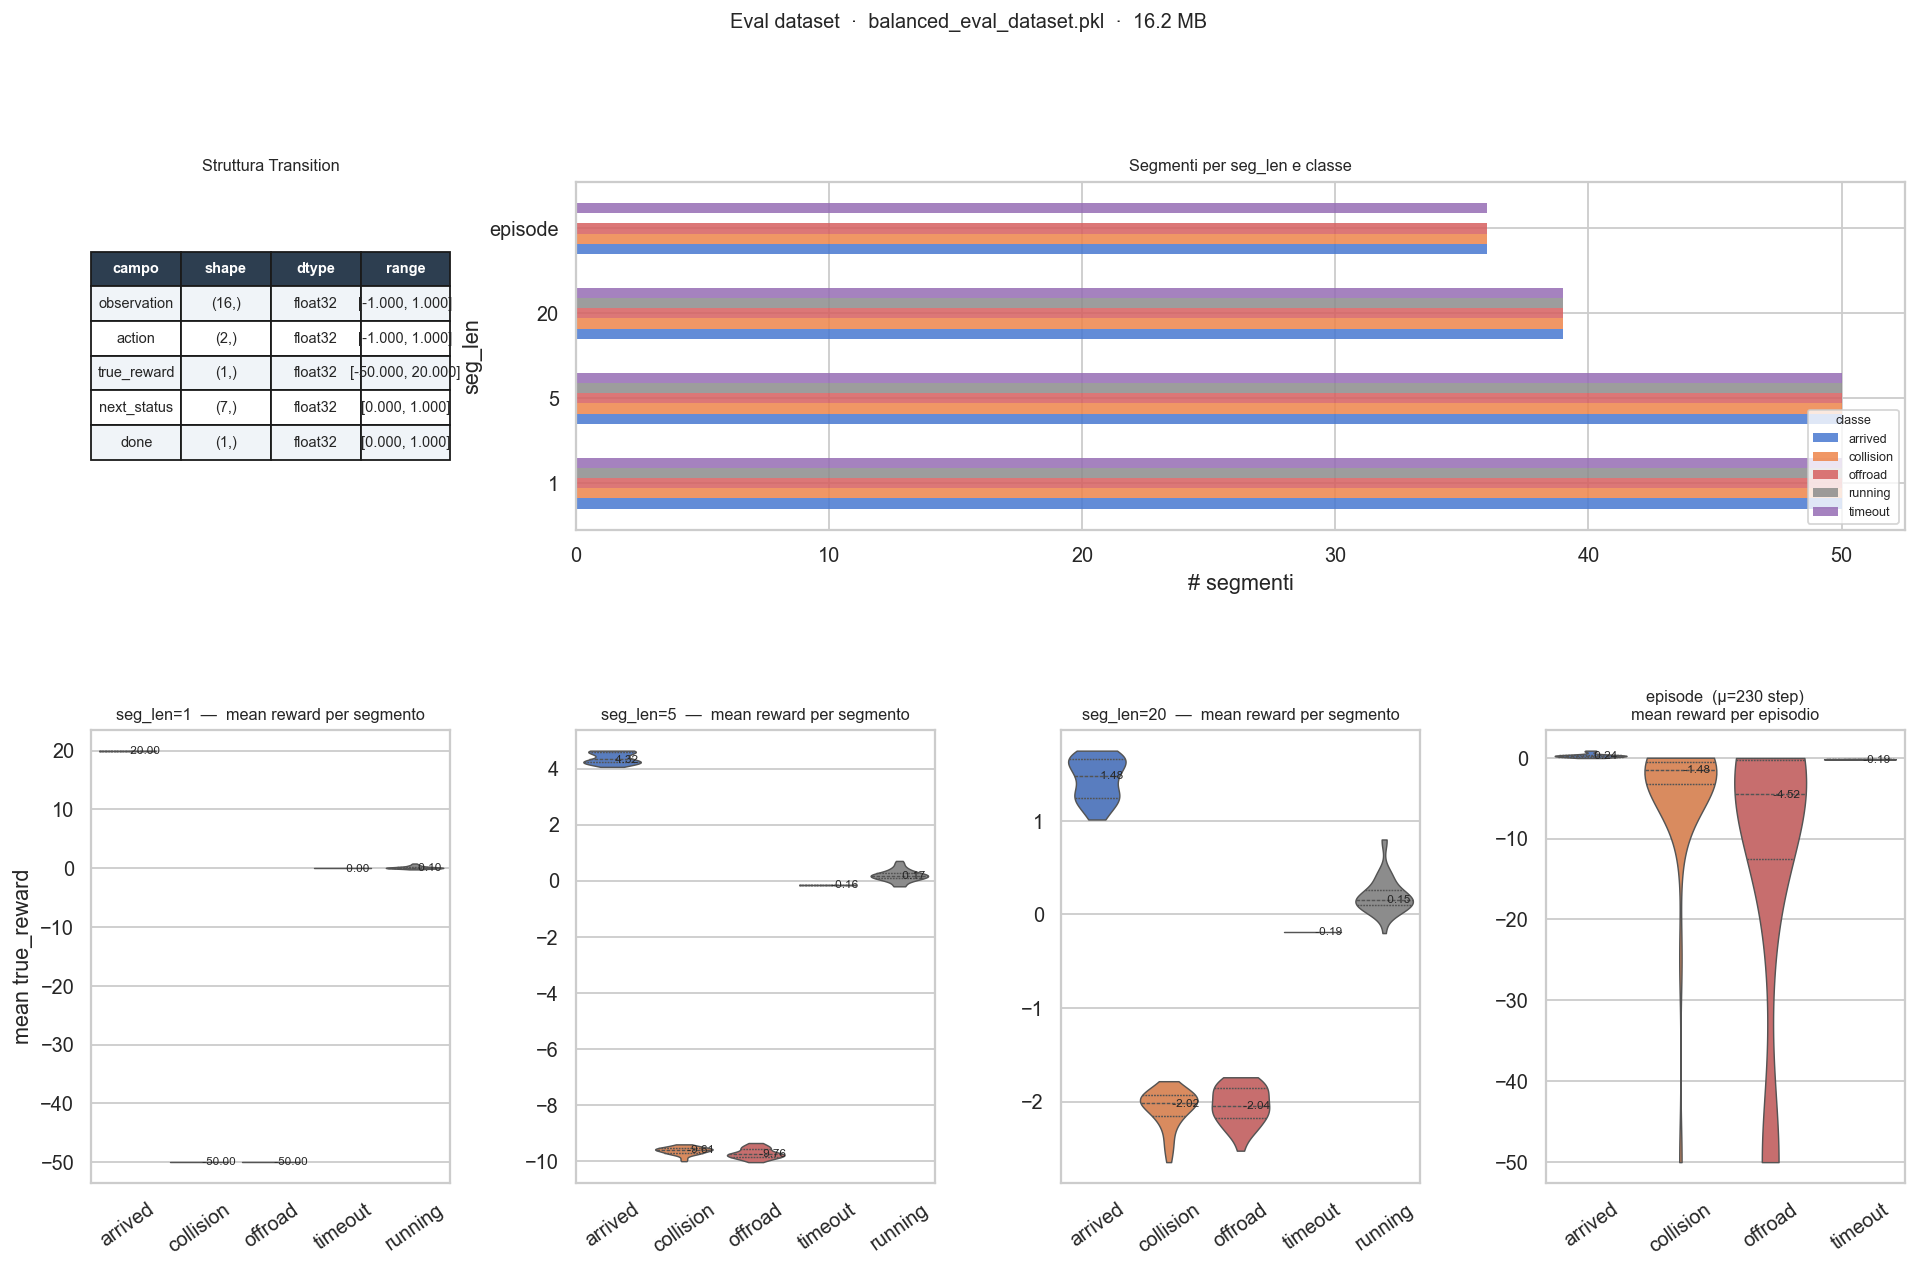

In [52]:
# cella per esaminare Dataset eval

import os
from collections import Counter

_SL = STATUS_LABELS
_SC = {0:"#4878d0",1:"#ee854a",2:"#d65f5f",3:"#956cb4",4:"#8c8c8c",5:"#d5bb67",6:"#82c6e2"}
_CLS_COLORS = {"arrived":"#4878d0","collision":"#ee854a","offroad":"#d65f5f",
               "off_road":"#d65f5f","timeout":"#956cb4","running":"#8c8c8c"}

file_mb = os.path.getsize(EVAL_DATASET_PATH) / 1e6

# ── struttura dei campi ───────────────────────────────────────────────────────
_arrays = {"observation": obs, "action": actions,
           "true_reward": true_reward[:, None], "next_status": status, "done": done[:, None]}
_fields = [(name, str(arr.shape[1:]) if arr.ndim > 1 else "scalar",
            str(arr.dtype), f"[{arr.min():.3f}, {arr.max():.3f}]")
           for name, arr in _arrays.items()]

# ── lunghezza media episodi ───────────────────────────────────────────────────
if "episode" in eval_segments_by_length:
    _ep_lens = [len(list(seg)) for seg in eval_segments_by_length["episode"]]
    print(f"Episodi nel dataset: {len(_ep_lens)}")
    print(f"  lunghezza media:   {np.mean(_ep_lens):.1f} step")
    print(f"  lunghezza mediana: {np.median(_ep_lens):.1f} step")
    print(f"  range:             [{min(_ep_lens)}, {max(_ep_lens)}] step")
    print(f"  classi:            {Counter(eval_labels_by_length.get('episode', []))}")

# ── layout ────────────────────────────────────────────────────────────────────
_fixed_lens = [sl for sl in SEGMENT_LENGTHS
               if sl != "episode" and sl in eval_segments_by_length]
_has_episode = "episode" in eval_segments_by_length
_n_violin = len(_fixed_lens) + (1 if _has_episode else 0)

fig = plt.figure(figsize=(max(14, 4.5 * _n_violin), 10))
fig.suptitle(f"Eval dataset  ·  {EVAL_DATASET_PATH.name}  ·  {file_mb:.1f} MB",
             fontsize=11, y=1.01)

# riga 0: tabella (1 col) + bar chart bilanciamento (resto)
# riga 1: violin per ogni seg_len + episode
gs = fig.add_gridspec(2, max(2, _n_violin), hspace=0.5, wspace=0.35,
                      height_ratios=[1, 1.3])

ax_info = fig.add_subplot(gs[0, 0])
ax_bar  = fig.add_subplot(gs[0, 1:])
ax_viol = [fig.add_subplot(gs[1, c]) for c in range(_n_violin)]

# ── tabella struttura ─────────────────────────────────────────────────────────
ax_info.axis("off")
_col_labels = ["campo", "shape", "dtype", "range"]
_tbl = ax_info.table(cellText=_fields, colLabels=_col_labels,
                     cellLoc="center", loc="center")
_tbl.auto_set_font_size(False); _tbl.set_fontsize(8); _tbl.scale(1, 1.6)
for j in range(len(_col_labels)):
    _tbl[0, j].set_facecolor("#2d3e50")
    _tbl[0, j].set_text_props(color="white", fontweight="bold")
for i in range(len(_fields)):
    for j in range(len(_col_labels)):
        _tbl[i+1, j].set_facecolor("#f0f4f8" if i % 2 == 0 else "white")
ax_info.set_title("Struttura Transition", fontsize=9, pad=6)

# ── bar chart bilanciamento ───────────────────────────────────────────────────
_all_lens = sorted(eval_segments_by_length,
                   key=lambda k: (isinstance(k, str), k if isinstance(k, str) else 0))
_all_cls  = [c for c in ["arrived","collision","offroad","off_road","running","timeout"]
             if any(c in Counter(eval_labels_by_length.get(sl, [])) for sl in _all_lens)]
_bar_colors = {c: _CLS_COLORS.get(c, "gray") for c in _all_cls}

_bar_data = {}
for sl in _all_lens:
    _cnt = Counter(eval_labels_by_length.get(sl, []))
    _bar_data[str(sl)] = [_cnt.get(c, 0) for c in _all_cls]

_bar_df = pd.DataFrame(_bar_data, index=_all_cls).T
_bar_df.plot(kind="barh", ax=ax_bar,
             color=[_bar_colors[c] for c in _all_cls],
             edgecolor="none", alpha=0.85, width=0.6)
ax_bar.set_title("Segmenti per seg_len e classe", fontsize=9)
ax_bar.set_xlabel("# segmenti"); ax_bar.set_ylabel("seg_len")
ax_bar.legend(title="classe", fontsize=7, title_fontsize=7, loc="lower right")

# ── violin: reward media per segmento ────────────────────────────────────────
_violin_lens = _fixed_lens + (["episode"] if _has_episode else [])
_cls_order   = ["arrived","collision","offroad","off_road","timeout","running"]

for ax, sl in zip(ax_viol, _violin_lens):
    segs = eval_segments_by_length[sl]
    lbls = eval_labels_by_length.get(sl, [None]*len(segs))
    rows = []
    for seg, lbl in zip(segs, lbls):
        ts = list(seg) if hasattr(seg, "__iter__") and not hasattr(seg, "true_reward") else [seg]
        rows.append({"mean_reward": float(np.mean([t.true_reward for t in ts])), "classe": lbl})
    _df_v = pd.DataFrame(rows)
    _order_v = [c for c in _cls_order if c in _df_v["classe"].unique()]
    _pal_v   = {c: _CLS_COLORS.get(c, "gray") for c in _order_v}

    sns.violinplot(data=_df_v, x="classe", y="mean_reward", order=_order_v,
                   palette=_pal_v, inner="quartile", linewidth=0.8, ax=ax, cut=0)
    for i, cls in enumerate(_order_v):
        _med = _df_v.loc[_df_v["classe"]==cls, "mean_reward"].median()
        ax.text(i, _med, f" {_med:.2f}", va="center", ha="left", fontsize=6.5)

    if sl == "episode" and _has_episode:
        _mean_len = np.mean(_ep_lens)
        ax.set_title(f"episode  (μ={_mean_len:.0f} step)\nmean reward per episodio", fontsize=9)
    else:
        ax.set_title(f"seg_len={sl}  —  mean reward per segmento", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("mean true_reward" if sl == _violin_lens[0] else "")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(EXPERIMENT_ROOT / "analysis_tables" / "eval_dataset_overview.png",
            bbox_inches="tight", dpi=150)
plt.show()


## Trova e descrive le run

La cella seguente legge i nomi delle cartelle create dallo script. Per nomi diversi, modificare `parse_run_metadata`.

In [53]:
def natural_checkpoint_id(path: Path):
    match = re.search(r"checkpoint_(\d+)", path.name)
    return int(match.group(1)) if match else -1


def normalize_labels_type(labels_type):
    if labels_type is None or (isinstance(labels_type, float) and np.isnan(labels_type)):
        return "unknown"
    return str(labels_type).replace("binary_bernulli", "binary_bernoulli")


def label_family_from_type(labels_type):
    labels_type = normalize_labels_type(labels_type)
    if labels_type == "binary":
        return "binary"
    if labels_type == "binary_bernoulli":
        return "bernoulli"
    if labels_type == "soft":
        return "soft"
    if labels_type == "baseline":
        return "baseline"
    return labels_type


def parse_run_metadata(run_dir: Path):
    name = run_dir.name
    is_baseline = bool(re.search(r"ppo_baseline", name))
    label_match = re.search(r"ppo_chri_([^ ]+)", name)
    q_match = re.search(r"q=(\d+)", name)
    temp_match = re.search(r"temp=([0-9.]+)", name)
    seed_match = re.search(r"seed=(\d+)", name)
    suffix_match = re.search(r"seed=\d+\s+(.+)$", name)

    if is_baseline:
        labels_type = "baseline"
    else:
        labels_type = normalize_labels_type(label_match.group(1) if label_match else "unknown")
    total_queries = int(q_match.group(1)) if q_match else np.nan
    temperature = float(temp_match.group(1)) if temp_match else np.nan
    seed = int(seed_match.group(1)) if seed_match else np.nan
    name_suffix = suffix_match.group(1) if suffix_match else None

    return {
        "run_name": name,
        "labels_type": labels_type,
        "label_family": label_family_from_type(labels_type),
        "total_queries": total_queries,
        "temperature": temperature,
        "seed": seed,
        "name_suffix": name_suffix,
    }


def find_runs(experiment_root: Path):
    roots = []
    if experiment_root.exists():
        roots.append(experiment_root)
        roots.extend([p for p in experiment_root.iterdir() if p.is_dir()])

    run_dirs = []
    for root in roots:
        # run con reward model
        for p in root.rglob("checkpoint_*"):
            if (p / "reward_model.pt").exists():
                run_dirs.append(p.parent)
        # run baseline (PPO con true reward): nessun checkpoint, solo cartella wandb
        for p in root.iterdir():
            if p.is_dir() and re.search(r"ppo_baseline", p.name) and (p / "wandb").exists():
                run_dirs.append(p)
    return sorted(set(run_dirs), key=lambda p: str(p))


run_dirs = find_runs(EXPERIMENT_ROOT)
if not run_dirs:
    raise FileNotFoundError(
        f"Nessuna run con checkpoint trovata sotto {EXPERIMENT_ROOT}. "
        "Controlla EXPERIMENT_ROOT."
    )

run_table = pd.DataFrame([{**parse_run_metadata(p), "run_dir": p} for p in run_dirs])
run_table = run_table.sort_values(["label_family", "total_queries", "temperature", "seed", "run_name"])
print(f"Run trovate localmente: {len(run_table)}")


Run trovate localmente: 81


## WandB API: link, stato run e metriche loggate

Questa sezione è opzionale. Usa la WandB API per collegare le run locali ai run remoti, aggiungere link cliccabili e leggere le metriche già loggate durante il training.

Se non sei loggata o non hai rete, il notebook stampa un warning e continua con i soli checkpoint locali.

In [54]:
def nested_get(d, path, default=np.nan):
    cur = d
    for key in path:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def load_wandb_run_index():
    if not USE_WANDB:
        return pd.DataFrame(), None
    try:
        import wandb
        api = wandb.Api()
        runs = list(api.runs(WANDB_PATH))
    except Exception as exc:
        print(f"WandB non disponibile: {exc}")
        return pd.DataFrame(), None

    rows = []
    for run in runs:
        cfg = dict(run.config or {})
        labels_type = normalize_labels_type(nested_get(cfg, ["algo", "kwargs", "labels_type"], None))
        total_queries            = nested_get(cfg, ["train", "kwargs", "total_queries"], np.nan)
        total_timesteps          = nested_get(cfg, ["train", "kwargs", "total_timesteps"], np.nan)
        timesteps_per_iteration  = nested_get(cfg, ["train", "kwargs", "timesteps_per_iteration"], np.nan)
        temperature = nested_get(cfg, ["algo", "kwargs", "temperature"], np.nan)
        seed = nested_get(cfg, ["run", "seed"], np.nan)
        name_suffix = nested_get(cfg, ["run", "name_suffix"], None)

        # Baseline PPO (true reward): nessun labels_type in config → riconosci dal nome run
        if labels_type == "unknown" and (
            "baseline" in (run.name or "").lower()
            or "baseline" in str(name_suffix or "").lower()
        ):
            labels_type = "baseline"
            if pd.isna(total_queries):
                _q = re.search(r"q=(\d+)", run.name or "")
                if _q:
                    total_queries = int(_q.group(1))
            if pd.isna(seed):
                _s = re.search(r"seed=(\d+)", run.name or "")
                if _s:
                    seed = int(_s.group(1))

        rows.append({
            "wandb_id": run.id,
            "wandb_name": run.name,
            "wandb_url": run.url,
            "wandb_state": run.state,
            "wandb_group": run.group,
            "wandb_tags": list(run.tags),
            "created_at": run.created_at,
            "runtime_sec": dict(run.summary or {}).get("_runtime", np.nan),
            "last_step": dict(run.summary or {}).get("_step", np.nan),
            "labels_type": labels_type,
            "label_family": label_family_from_type(labels_type),
            "total_queries":           int(total_queries)           if pd.notna(total_queries)           else np.nan,
            "total_timesteps":         int(total_timesteps)         if pd.notna(total_timesteps)         else np.nan,
            "timesteps_per_iteration": int(timesteps_per_iteration) if pd.notna(timesteps_per_iteration) else np.nan,
            "temperature": float(temperature) if pd.notna(temperature) else np.nan,
            "seed": int(seed) if pd.notna(seed) else np.nan,
            "name_suffix": name_suffix,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df, api
    return df.sort_values(["label_family", "total_queries", "temperature", "seed", "created_at"]), api


wandb_runs, wandb_api = load_wandb_run_index()
print(f"Run trovate su WandB: {len(wandb_runs)}")
wandb_runs.head()


Run trovate su WandB: 81


,wandb_id,wandb_name,wandb_url,wandb_state,wandb_group,wandb_tags,created_at,runtime_sec,last_step,labels_type,label_family,total_queries,total_timesteps,timesteps_per_iteration,temperature,seed,name_suffix
2,1zqknyzs,ppo_chri_binary_bernoulli seg=1 q=10000 temp=2...,https://wandb.ai/andrea02polimi-politecnico-di...,finished,ppo_chri_binary_bernoulli seg=1,"[bernoulli_10k, binary_bernoulli, paper]",2026-06-10T09:52:16Z,2925,605,binary_bernoulli,bernoulli,10000,2000000,20000,20.0,0,bernoulli_10k
46,nvzqiv2u,ppo_baseline q=10000 temp=20.0 seed=0 ppo_true...,https://wandb.ai/andrea02polimi-politecnico-di...,finished,ppo_baseline,"[all, baseline, missing, ppo_true_reward_basel...",2026-06-14T00:33:28Z,5357,499,binary_bernoulli,bernoulli,10000,2000000,20000,20.0,0,ppo_true_reward_baseline
12,2p1iexpt,ppo_chri_binary_bernoulli seg=1 q=10000 temp=2...,https://wandb.ai/andrea02polimi-politecnico-di...,finished,ppo_chri_binary_bernoulli seg=1,"[bernoulli_10k, binary_bernoulli, paper]",2026-06-10T19:00:35Z,3272,605,binary_bernoulli,bernoulli,10000,2000000,20000,20.0,1,bernoulli_10k
63,jl5rsmou,ppo_baseline q=10000 temp=20.0 seed=1 ppo_true...,https://wandb.ai/andrea02polimi-politecnico-di...,finished,ppo_baseline,"[all, baseline, missing, ppo_true_reward_basel...",2026-06-14T10:51:56Z,2789,499,binary_bernoulli,bernoulli,10000,2000000,20000,20.0,1,ppo_true_reward_baseline
22,wr8e5qcf,ppo_chri_binary_bernoulli seg=1 q=10000 temp=2...,https://wandb.ai/andrea02polimi-politecnico-di...,finished,ppo_chri_binary_bernoulli seg=1,"[bernoulli_10k, binary_bernoulli, paper]",2026-06-11T04:51:33Z,2763,605,binary_bernoulli,bernoulli,10000,2000000,20000,20.0,2,bernoulli_10k


In [55]:
def same_or_missing(a, b):
    if pd.isna(a) or pd.isna(b):
        return True
    return a == b


def attach_wandb_links(local_runs, remote_runs):
    local_runs = local_runs.copy()
    if remote_runs.empty:
        for col in ("wandb_url", "wandb_state", "runtime_sec", "total_timesteps", "timesteps_per_iteration"):
            local_runs[col] = np.nan
        return local_runs

    urls, states, runtimes, ids = [], [], [], []
    total_timesteps_list, tpi_list = [], []

    for _, local in local_runs.iterrows():
        candidates = remote_runs[
            (remote_runs["label_family"] == local["label_family"]) &
            (remote_runs["labels_type"] == local["labels_type"]) &
            (remote_runs["seed"] == local["seed"])
        ].copy()

        if pd.notna(local["total_queries"]):
            candidates = candidates[candidates["total_queries"] == local["total_queries"]]
        if pd.notna(local["temperature"]):
            candidates = candidates[np.isclose(candidates["temperature"], local["temperature"])]
        if local.get("name_suffix") and "name_suffix" in candidates:
            suffix_match = candidates[candidates["name_suffix"] == local["name_suffix"]]
            if not suffix_match.empty:
                candidates = suffix_match

        if candidates.empty:
            urls.append(np.nan); states.append(np.nan)
            runtimes.append(np.nan); ids.append(np.nan)
            total_timesteps_list.append(np.nan); tpi_list.append(np.nan)
            continue

        chosen = candidates.sort_values("created_at").iloc[-1]
        urls.append(chosen["wandb_url"]); states.append(chosen["wandb_state"])
        runtimes.append(chosen["runtime_sec"]); ids.append(chosen["wandb_id"])
        total_timesteps_list.append(chosen.get("total_timesteps", np.nan))
        tpi_list.append(chosen.get("timesteps_per_iteration", np.nan))

    local_runs["wandb_id"]                = ids
    local_runs["wandb_url"]               = urls
    local_runs["wandb_state"]             = states
    local_runs["runtime_sec"]             = runtimes
    local_runs["total_timesteps"]         = total_timesteps_list
    local_runs["timesteps_per_iteration"] = tpi_list
    local_runs["wandb_link"] = local_runs["wandb_url"].map(
        lambda url: f'<a href="{url}" target="_blank">wandb</a>'
        if isinstance(url, str) and url else ""
    )
    return local_runs


run_table = attach_wandb_links(run_table, wandb_runs)

In [ ]:
import ipywidgets as widgets

unified = run_table.copy()

# num_iterations e num_queries_per_iteration derivati dai parametri della run (da WandB config)
unified["num_iterations"] = (
    unified["total_timesteps"] / unified["timesteps_per_iteration"]
).round().astype("Int64")

unified["num_queries_per_iteration"] = (
    unified["total_queries"] / unified["num_iterations"]
).round().astype("Int64")

UNIFIED_COLS = [
    "run_name",
    "label_family",
    "num_queries_per_iteration",
    "num_iterations",
    "temperature",
    "seed",
    "runtime_sec",
    "wandb_link",
    "run_dir",
]

SORT_OPTS = [
    "label_family", "num_queries_per_iteration", "temperature",
    "seed", "runtime_sec",
]

_families = sorted(unified["label_family"].dropna().unique().tolist())

w_family = widgets.SelectMultiple(
    options=_families, value=_families,
    description="famiglia", rows=min(len(_families), 5),
    layout=widgets.Layout(width="180px"),
)
w_sort = widgets.Dropdown(
    options=SORT_OPTS, value="label_family",
    description="ordina per", layout=widgets.Layout(width="240px"),
)
w_asc = widgets.ToggleButtons(
    options=[("↑ asc", True), ("↓ desc", False)],
    value=True, description="",
    style={"button_width": "70px"},
)
w_reset = widgets.Button(
    description="Reset", button_style="warning",
    layout=widgets.Layout(width="90px"),
)

out_u = widgets.Output()


def _render_unified(*_):
    df = unified.copy()
    if w_family.value:
        df = df[df["label_family"].isin(w_family.value)]
    df = df.sort_values(w_sort.value, ascending=w_asc.value, na_position="last")
    with out_u:
        out_u.clear_output(wait=True)
        display(HTML(
            f"<b>{len(df)}</b> / {len(unified)} run"
            '<div style="overflow-x: auto; white-space: nowrap;">' +
            df[UNIFIED_COLS].to_html(escape=False, index=False) +
            "</div>"
        ))


def _reset_unified(_):
    w_family.value = _families
    w_sort.value   = "label_family"
    w_asc.value    = True


w_family.observe(_render_unified, names="value")
w_sort.observe(_render_unified,   names="value")
w_asc.observe(_render_unified,    names="value")
w_reset.on_click(_reset_unified)
w_reset.on_click(lambda _: _render_unified())

controls_u = widgets.HBox([
    widgets.VBox([widgets.Label("Filtra famiglia:"), w_family]),
    widgets.VBox([widgets.Label("Ordina per:"), w_sort, w_asc]),
    widgets.VBox([widgets.Label(""), w_reset]),
], layout=widgets.Layout(gap="24px", align_items="flex-start"))

display(controls_u, out_u)
_render_unified()

Output()

In [64]:
# ── Iperparametri fissi vs sweep ─────────────────────────────────────────────

def _flatten(d, prefix="", sep="."):
    """Appiattisce un dizionario annidato con chiavi puntate."""
    out = {}
    for k, v in d.items():
        key = f"{prefix}{sep}{k}" if prefix else k
        if isinstance(v, dict):
            out.update(_flatten(v, key, sep))
        else:
            out[key] = v
    return out


def _fmt_val(v):
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    if isinstance(v, (list, tuple)) and len(v) > 6:
        return f"[{', '.join(str(x) for x in v[:4])}, ...]"
    return str(v)


if wandb_api is not None:
    _sample_runs = wandb_runs.dropna(subset=["wandb_id"])
    _all_configs = []
    for _, row in _sample_runs.iterrows():
        try:
            _run = wandb_api.run(f"{WANDB_PATH}/{row['wandb_id']}")
            _all_configs.append(_flatten(dict(_run.config or {})))
        except Exception:
            continue

    if _all_configs:
        # Chiavi presenti in tutte le run
        _common_keys = set(_all_configs[0]).intersection(*[set(c) for c in _all_configs[1:]])

        fixed_rows, sweep_rows = [], []
        for key in sorted(_common_keys):
            vals = [c[key] for c in _all_configs]
            # Confronto robusto: serializza per gestire liste/dict
            _str_vals = [str(v) for v in vals]
            unique_str = sorted(set(_str_vals))
            if len(unique_str) == 1:
                fixed_rows.append({"parametro": key, "valore": _fmt_val(vals[0])})
            else:
                # Mostra valori distinti (non le stringhe serializzate)
                _unique_vals = []
                _seen = set()
                for v in vals:
                    s = str(v)
                    if s not in _seen:
                        _seen.add(s)
                        _unique_vals.append(v)
                _unique_vals.sort(key=lambda x: (str(type(x).__name__), str(x)))
                sweep_rows.append({
                    "parametro": key,
                    "valori distinti": ", ".join(_fmt_val(v) for v in _unique_vals),
                    "n valori": len(_unique_vals),
                })

        print(f"Run totali: {len(_sample_runs)}  |  Config caricati: {len(_all_configs)}  |  "
              f"Chiavi comuni: {len(_common_keys)}  |  "
              f"Fissi: {len(fixed_rows)}  |  Sweep: {len(sweep_rows)}")

        print("\n── Iperparametri FISSI (identici in tutte le run) ──────────────────────")
        _fixed_df = pd.DataFrame(fixed_rows)
        display(_fixed_df.style.set_properties(**{"text-align": "left"})
                .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
                .hide(axis="index"))

        print("\n── Iperparametri in SWEEP (variano tra run) ────────────────────────────")
        _sweep_df = pd.DataFrame(sweep_rows)
        display(_sweep_df.style.set_properties(**{"text-align": "left"})
                .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
                .hide(axis="index"))
    else:
        print("Nessun config caricato da WandB.")
else:
    print("WandB non disponibile — skip analisi iperparametri.")


Run totali: 81  |  Config caricati: 81  |  Chiavi comuni: 45  |  Fissi: 35  |  Sweep: 10

── Iperparametri FISSI (identici in tutte le run) ──────────────────────


parametro,valore
agent.kwargs.batch_size,64
agent.kwargs.device,cpu
agent.kwargs.ent_coef,0
agent.kwargs.gae_lambda,0.95
agent.kwargs.gamma,0.997
agent.kwargs.learning_rate,0.0003
agent.kwargs.n_epochs,10
agent.kwargs.n_steps,1000
agent.kwargs.policy,MlpPolicy
agent.kwargs.policy_kwargs.net_arch,"[64, 64]"



── Iperparametri in SWEEP (variano tra run) ────────────────────────────


parametro,valori distinti,n valori
algo.kwargs.initial_queries,"10, 100, 1000, 10000, 20, 200, 2000, 40, 4000",9
algo.kwargs.labels_type,"binary, binary_bernoulli, binary_bernulli, soft",4
algo.kwargs.temperature,"10, 15, 20, 30, 5, 50",6
group_name,"ppo_baseline, ppo_chri_binary seg=1, ppo_chri_binary_bernoulli seg=1, ppo_chri_soft seg=1",4
run.baseline,"False, True",2
run.name_suffix,"bernoulli_100k, bernoulli_100k_T10, bernoulli_100k_T5, bernoulli_100k_T50, bernoulli_10k, bernoulli_200k_T20, bernoulli_500k_T20, bernoulli_50k, deterministic_binary_100k, deterministic_binary_10k, deterministic_binary_50k, ppo_true_reward_baseline, soft_10k_T10, soft_10k_T15, soft_10k_T20, soft_10k_T30, soft_10k_T5, soft_10k_T50, soft_1k_T20, soft_2k_T10, soft_2k_T15, soft_2k_T20, soft_2k_T30, soft_2k_T5, soft_2k_T50, soft_500_T20, soft_5k_T20",27
run.output_dir,"/work/fis3/sumo-human-feedback-rl/outputs/reward_label_experiments/20260610_092001, /work/fis3/sumo-human-feedback-rl/outputs/reward_label_experiments/missing_20260613_170444",2
run.seed,"0, 1, 2",3
train.kwargs.total_queries,"1000, 10000, 100000, 2000, 200000, 500, 5000, 50000, 500000",9
wandb.tags,"['missing', 'all', 'baseline', 'ppo_true_reward_baseline'], ['missing', 'all', 'binary', 'deterministic_binary_100k'], ['missing', 'all', 'binary_bernoulli', 'bernoulli_100k_T10'], ['missing', 'all', 'binary_bernoulli', 'bernoulli_100k_T5'], ['missing', 'all', 'binary_bernoulli', 'bernoulli_100k_T50'], ['missing', 'all', 'binary_bernoulli', 'bernoulli_200k_T20'], ['missing', 'all', 'binary_bernoulli', 'bernoulli_500k_T20'], ['missing', 'all', 'soft', 'soft_10k_T10'], ['missing', 'all', 'soft', 'soft_10k_T15'], ['missing', 'all', 'soft', 'soft_10k_T30'], ['missing', 'all', 'soft', 'soft_1k_T20'], ['missing', 'all', 'soft', 'soft_2k_T10'], ['missing', 'all', 'soft', 'soft_2k_T15'], ['missing', 'all', 'soft', 'soft_2k_T30'], ['missing', 'all', 'soft', 'soft_2k_T5'], ['missing', 'all', 'soft', 'soft_2k_T50'], ['missing', 'all', 'soft', 'soft_500_T20'], ['paper', 'binary', 'deterministic_binary_10k'], ['paper', 'binary', 'deterministic_binary_50k'], ['paper', 'binary_bernoulli', 'bernoulli_100k'], ['paper', 'binary_bernoulli', 'bernoulli_10k'], ['paper', 'binary_bernoulli', 'bernoulli_50k'], ['paper', 'soft', 'soft_10k_T20'], ['paper', 'soft', 'soft_10k_T5'], ['paper', 'soft', 'soft_10k_T50'], ['paper', 'soft', 'soft_2k_T20'], ['paper', 'soft', 'soft_5k_T20']",27


## Metriche sui checkpoint

- `spearman`: correlazione di ranking tra reward vera e predetta — misura se il modello impara **l'ordine** delle reward (↑ meglio, ideale = 1).
- `ols_slope`: pendenza della retta `pred ~ true` — misura se il modello impara anche la **scala** delle reward, non solo l'ordine (↑ meglio, ideale = 1).

Questa coppia separa bene le ipotesi: `binary` tende ad avere Spearman alto ma slope ≈ 0 (impara l'ordine, non la scala); `soft` dovrebbe avvicinare lo slope a 1.

Lo scatter più corretto è quello con `ALIGNMENT = "zscore"` o almeno `"mean"`, perché dalle preferenze l'offset assoluto non è identificabile.

In [60]:
def make_segments(length: int):
    """Fallback for legacy flat-transition eval datasets."""
    if length == 1:
        return [(i, i + 1) for i in range(len(true_reward))]
    return [(i, min(i + length, len(true_reward))) for i in range(0, len(true_reward) - length + 1, length)]


def align_predictions(y_true, y_pred, mode="zscore", mask=None):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    if mode == "none":
        return y_pred
    if mask is None or not np.any(mask):
        mask = np.ones(len(y_true), dtype=bool)
    true_mean = y_true[mask].mean()
    pred_mean = y_pred[mask].mean()
    if mode == "mean":
        return y_pred - pred_mean + true_mean
    if mode == "zscore":
        true_std = y_true[mask].std() + 1e-8
        pred_std = y_pred[mask].std() + 1e-8
        return (y_pred - pred_mean) / pred_std * true_std + true_mean
    raise ValueError(f"Unknown alignment mode: {mode}")


def safe_corr(fn, x, y):
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return fn(x, y)[0]


def _score_explicit_segments(rm, segments, labels=None):
    rows = []
    for idx, seg in enumerate(segments):
        obs_seg = np.asarray([t.observation for t in seg], dtype=np.float32)
        act_seg = np.asarray([t.action for t in seg], dtype=np.float32)
        status_seg = np.asarray([t.next_status for t in seg], dtype=np.float32)
        done_seg = np.asarray([float(t.done) for t in seg], dtype=np.float32)
        pred_seg = rm.predict(obs_seg, act_seg, status_seg, done_seg)
        status_id = int(np.argmax(seg[-1].next_status))
        label = labels[idx] if labels is not None else STATUS_LABELS.get(status_id, "unknown")
        rows.append({
            "true": float(np.mean([t.true_reward for t in seg])),
            "pred_raw": float(np.mean(pred_seg)),
            "status": status_id,
            "label": label,
            "running": bool(label == "running" or status_id == STATUS_RUNNING),
        })
    return pd.DataFrame(rows)


def _score_flat_transitions(rm, segment_length):
    pred_step = rm.predict(obs, actions, status, done)
    rows = []
    for start, end in make_segments(segment_length):
        status_id = int(terminal_status[end - 1])
        rows.append({
            "true": float(true_reward[start:end].mean()),
            "pred_raw": float(pred_step[start:end].mean()),
            "status": status_id,
            "label": STATUS_LABELS.get(status_id, "unknown"),
            "running": bool(status[start:end, STATUS_RUNNING].mean() > 0.5),
        })
    return pd.DataFrame(rows)


def score_checkpoint(checkpoint_dir: Path, segment_length: int):
    rm = load_reward_ensemble(checkpoint_dir / "reward_model.pt", obs_space, action_space)

    if USING_BALANCED_SEGMENTS:
        segments = eval_segments_by_length[segment_length]
        labels = eval_labels_by_length.get(segment_length)
        df = _score_explicit_segments(rm, segments, labels)
    else:
        df = _score_flat_transitions(rm, segment_length)

    norm_mask = df["running"].to_numpy()
    df["pred"] = align_predictions(df["true"], df["pred_raw"], ALIGNMENT, norm_mask)
    return df


def metrics_from_scores(df):
    y_true = np.asarray(df["true"], dtype=np.float64)
    y_pred = np.asarray(df["pred"], dtype=np.float64)
    residual = y_pred - y_true
    slope, intercept = np.polyfit(y_true, y_pred, deg=1) if len(df) >= 2 else (np.nan, np.nan)

    ss_res  = float(np.sum(residual ** 2))
    ss_tot  = float(np.sum((y_true - y_true.mean()) ** 2))
    r2      = float(1 - ss_res / ss_tot) if ss_tot > 1e-12 else np.nan

    rmse      = float(np.sqrt(np.mean(residual ** 2)))
    true_std  = float(y_true.std())
    rmse_norm = rmse / true_std if true_std > 1e-12 else np.nan

    return {
        "r2":                 r2,
        "rmse_norm":          rmse_norm,
        "spearman":           safe_corr(spearmanr, y_true, y_pred),
        "ols_slope":     float(slope),
        "rmse":               rmse,
        "mae":                float(np.mean(np.abs(residual))),
        "bias":               float(np.mean(residual)),
        "pearson":            safe_corr(pearsonr, y_true, y_pred),
        "ols_intercept": float(intercept),
        "n_points":           len(df),
    }


def checkpoints_for_run(run_dir: Path):
    ckpts = sorted(
        [p for p in run_dir.glob("checkpoint_*") if (p / "reward_model.pt").exists()],
        key=natural_checkpoint_id,
    )
    return ckpts[-1:] if FINAL_ONLY else ckpts

In [62]:
metric_rows = []
score_cache = {}

for _, run in run_table.iterrows():
    run_dir = Path(run["run_dir"])
    for ckpt in checkpoints_for_run(run_dir):
        checkpoint_id = natural_checkpoint_id(ckpt)
        for seg_len in SEGMENT_LENGTHS:
            scores = score_checkpoint(ckpt, seg_len)
            key = (str(run_dir), checkpoint_id, seg_len)
            score_cache[key] = scores
            metric_rows.append({
                **{k: run[k] for k in ["run_name", "labels_type", "label_family", "total_queries", "temperature", "seed"]},
                "run_dir": run_dir,
                "checkpoint_dir": ckpt,
                "checkpoint": checkpoint_id,
                "segment_length": seg_len,
                **metrics_from_scores(scores),
            })

metrics = pd.DataFrame(metric_rows)
metrics = metrics.sort_values(["segment_length", "label_family", "total_queries", "temperature", "seed", "checkpoint"])

# ── anteprima: ultimo checkpoint per configurazione, media su seed ────────────
_SHOW_METRICS = ["spearman", "ols_slope"]
_preview = (
    metrics[metrics["segment_length"] == 1]
    .sort_values("checkpoint")
    .groupby(["run_name", "label_family", "total_queries", "temperature", "seed"], as_index=False)
    .tail(1)
    .groupby(["label_family", "total_queries", "temperature"])[_SHOW_METRICS]
    .mean()
    .reset_index()
    .sort_values(["label_family", "total_queries", "temperature"])
)

_fmt = {"total_queries": "{:.0f}", "temperature": "{:.0f}"}
_fmt.update({m: "{:.3f}" for m in _SHOW_METRICS})

display(
    _preview.style
    .background_gradient(subset=_SHOW_METRICS, cmap="RdYlGn", axis=0)
    .format(_fmt)
    .set_caption(f"Ultimo checkpoint · seg=1 · alignment={ALIGNMENT}  — media su seed  (verde = migliore per colonna)")
)

,label_family,total_queries,temperature,spearman,ols_slope
0,bernoulli,10000,20,0.883,0.050
1,bernoulli,50000,20,0.812,0.156
2,bernoulli,100000,5,0.937,0.384
3,bernoulli,100000,10,0.934,0.367
4,bernoulli,100000,20,0.927,0.298
5,bernoulli,100000,50,0.911,0.114
6,bernoulli,200000,20,0.933,0.290
7,bernoulli,500000,20,0.928,0.370
8,binary,10000,20,0.910,0.007
9,binary,50000,20,0.935,0.007


## Curva di apprendimento e confronto configurazioni

Il pannello di sinistra è la **heatmap riassuntiva**: ogni riga è una configurazione (tipo etichetta + query budget + temperatura), ogni colonna una metrica chiave. Il colore verde = meglio, rosso = peggio, normalizzato per colonna. I valori nelle celle sono media ± std sui tre seed.

I due pannelli a destra mostrano la **curva di apprendimento** di R² e RMSE/σ man mano che aumentano i checkpoint, per vedere se e quando il modello converge.

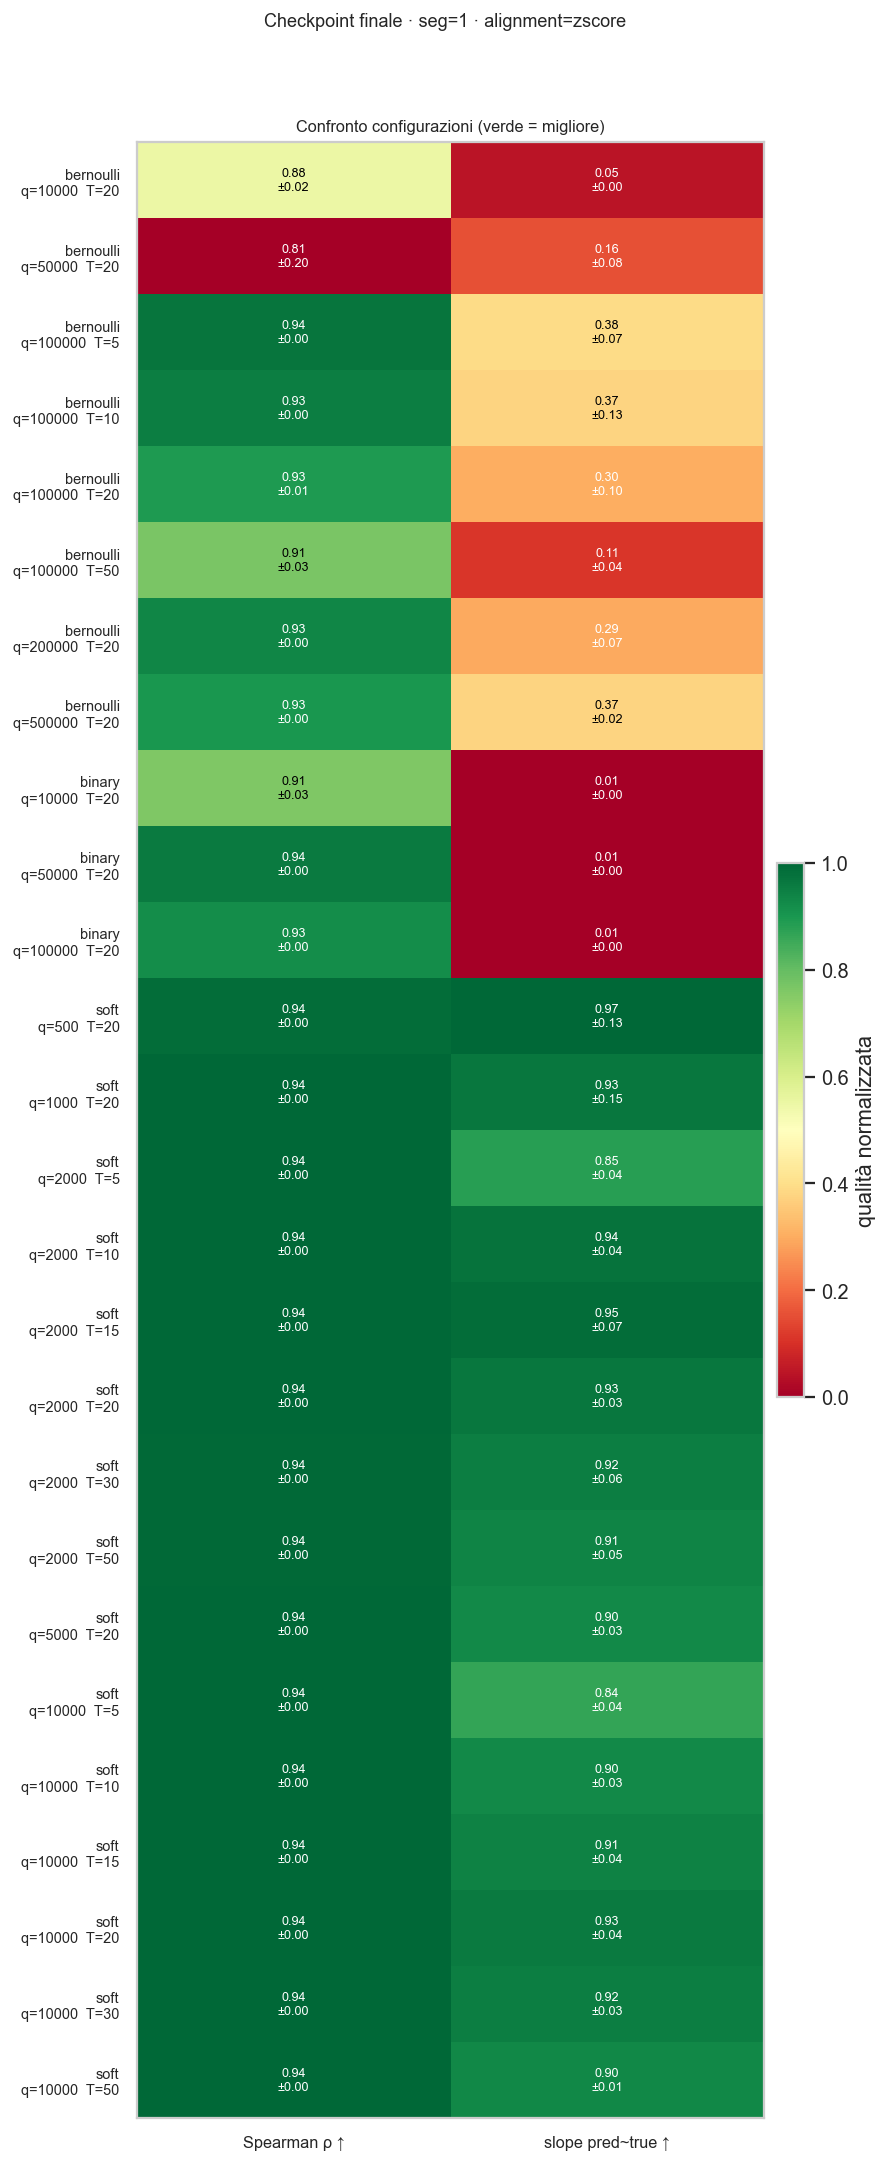

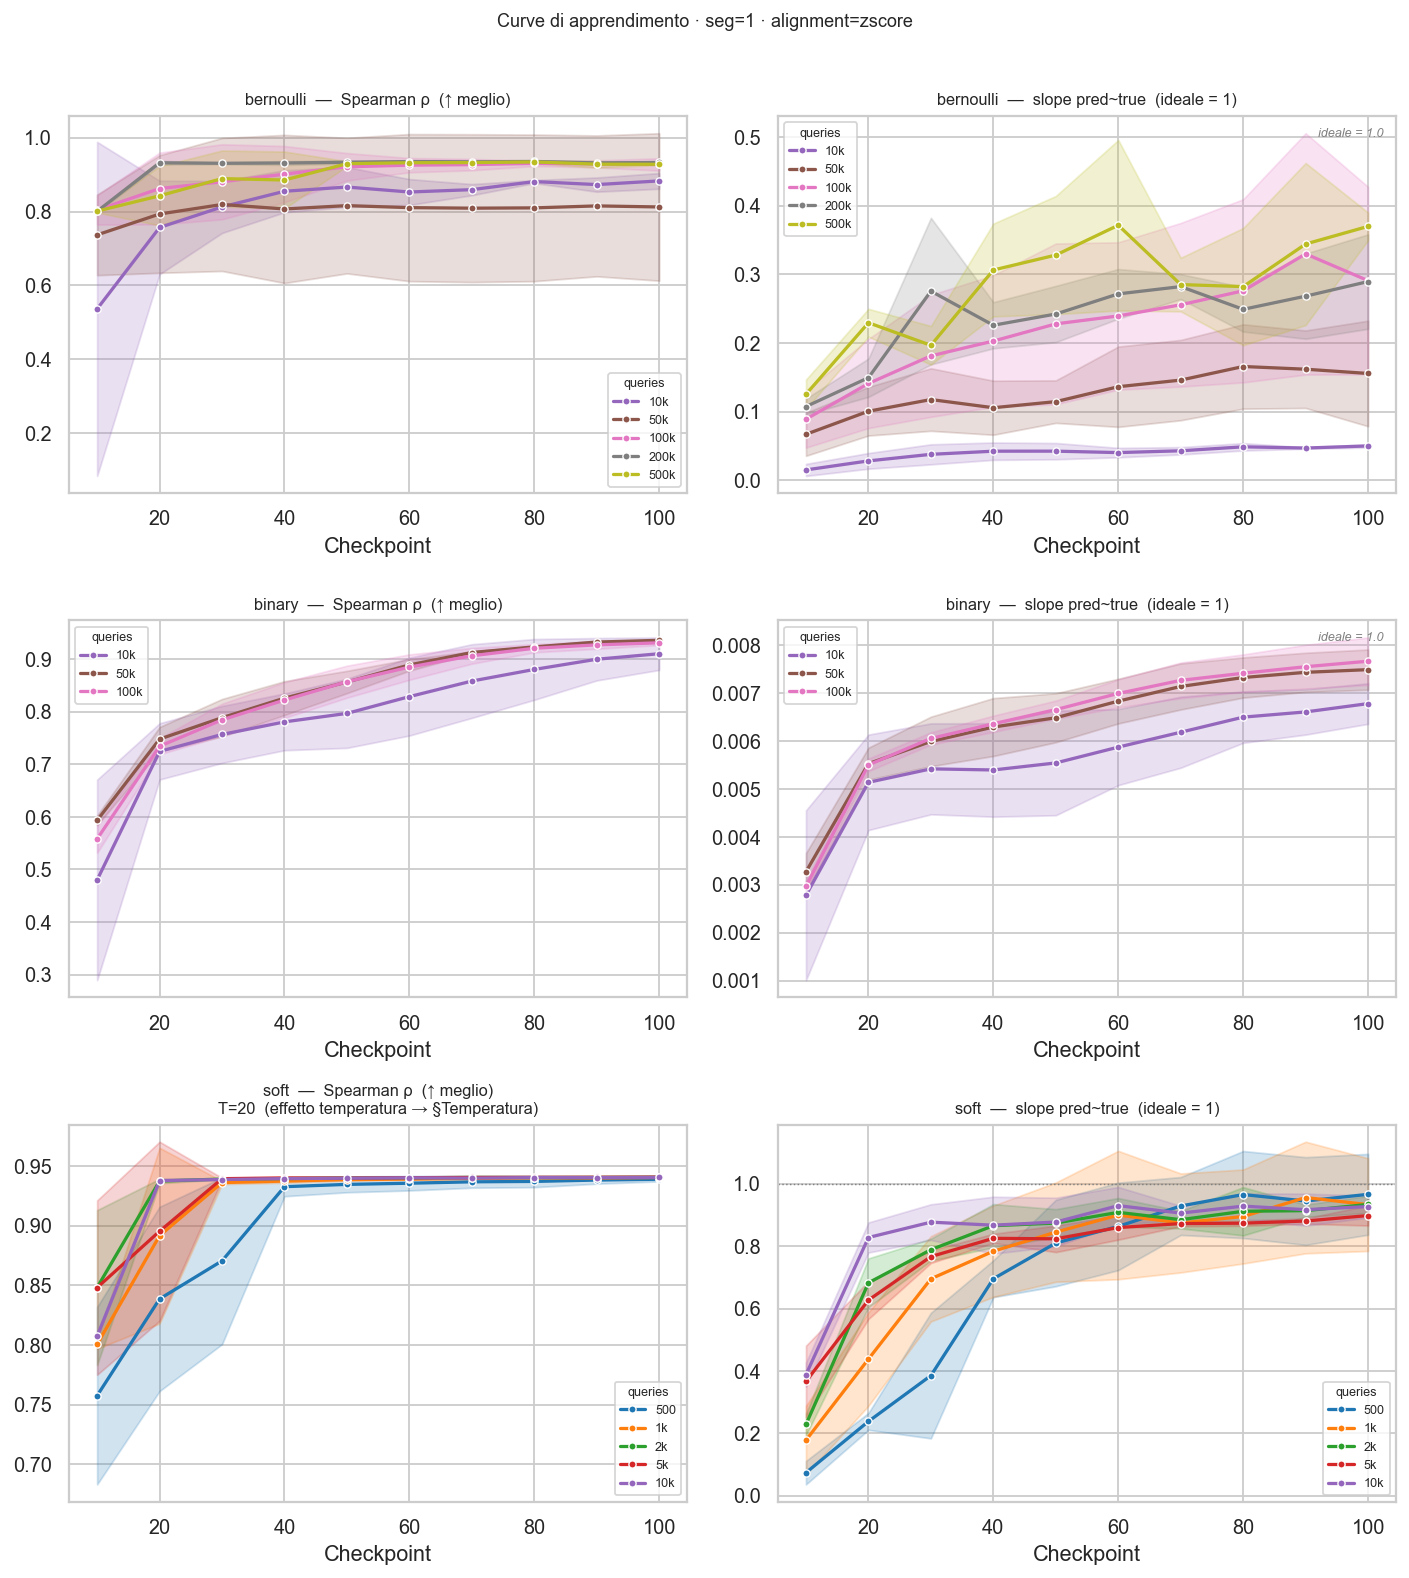

In [65]:
SEG_LEN = 1
curve_df = metrics[metrics["segment_length"] == SEG_LEN].copy()

# ── configura etichette riga ──────────────────────────────────────────────────
def _row_label(row):
    fam  = row["label_family"]
    q    = f"q={int(row['total_queries'])}" if pd.notna(row["total_queries"]) else ""
    temp = f"T={row['temperature']:g}"      if pd.notna(row["temperature"])   else ""
    return f"{fam}\n{q}  {temp}".strip()

# ── palette: colori distinguibili per budget di query ─────────────────────────
_all_q = sorted(curve_df["total_queries"].dropna().unique())
_Q_PALETTE = dict(zip(
    _all_q,
    sns.color_palette("tab10", len(_all_q)) if len(_all_q) <= 10
    else sns.color_palette("viridis", len(_all_q)),
))
_q_fmt = lambda q: f"{int(q)//1000}k" if q >= 1000 else str(int(q))

# Temperatura di riferimento per le curve soft (effetto T → vedi sezione Temperatura)
_SOFT_T_REF = 20.0

# ── 1.  Heatmap finale ────────────────────────────────────────────────────────
final_ck = (
    curve_df.sort_values("checkpoint")
    .groupby(["run_name", "label_family", "total_queries", "temperature", "seed"], as_index=False)
    .tail(1)
)

HM_METRICS = {
    "spearman":       ("Spearman ρ",     "↑"),
    "ols_slope": ("slope pred~true","↑"),
}

agg_mean = final_ck.groupby(["label_family","total_queries","temperature"])[list(HM_METRICS)].mean()
agg_std  = final_ck.groupby(["label_family","total_queries","temperature"])[list(HM_METRICS)].std()

norm = pd.DataFrame(index=agg_mean.index, columns=list(HM_METRICS), dtype=float)
for col, (_, direction) in HM_METRICS.items():
    col_min, col_max = agg_mean[col].min(), agg_mean[col].max()
    rng = col_max - col_min if (col_max - col_min) > 1e-12 else 1.0
    norm[col] = (agg_mean[col] - col_min) / rng if direction == "↑" else (col_max - agg_mean[col]) / rng

row_labels = [_row_label(pd.Series(dict(zip(["label_family","total_queries","temperature"], idx))))
              for idx in agg_mean.index]
col_labels = [f"{label} {arrow}" for col, (label, arrow) in HM_METRICS.items()]

fig_hm, ax_hm = plt.subplots(1, 1, figsize=(7, max(5, 0.55 * len(row_labels) + 2)))
fig_hm.suptitle(f"Checkpoint finale · seg={SEG_LEN} · alignment={ALIGNMENT}", fontsize=10, y=1.02)

ax_hm.grid(False)
im = ax_hm.imshow(norm.values.astype(float), cmap="RdYlGn", vmin=0, vmax=1,
                  aspect="auto", interpolation="nearest")
ax_hm.set_xticks(range(len(col_labels))); ax_hm.set_xticklabels(col_labels, fontsize=9)
ax_hm.set_yticks(range(len(row_labels))); ax_hm.set_yticklabels(row_labels, fontsize=8)
ax_hm.set_title("Confronto configurazioni (verde = migliore)", fontsize=9, pad=6)
for i in range(len(row_labels)):
    for j, col in enumerate(HM_METRICS):
        mu = agg_mean.iloc[i][col]
        sd = agg_std.iloc[i][col]
        sd_str  = f"\n±{sd:.2f}" if not np.isnan(sd) else ""
        val_str = "nan" if np.isnan(mu) else f"{mu:.2f}{sd_str}"
        text_color = "black" if 0.35 < norm.values[i, j] < 0.85 else "white"
        ax_hm.text(j, i, val_str, ha="center", va="center", fontsize=7, color=text_color)
plt.colorbar(im, ax=ax_hm, fraction=0.04, pad=0.02, label="qualità normalizzata")
plt.tight_layout()
plt.savefig(EXPERIMENT_ROOT / "analysis_tables" / "learning_curves_heatmap.png",
            bbox_inches="tight", dpi=150)
plt.show()

# ── 2.  Curve di apprendimento ────────────────────────────────────────────────
# Soft: filtrata a T=_SOFT_T_REF per confronto diretto con binary/bernoulli.
# L'effetto della temperatura è analizzato nella sezione dedicata (§Temperatura).
METRICS_CURVES = [
    ("spearman",       "Spearman ρ  (↑ meglio)",        None),
    ("ols_slope", "slope pred~true  (ideale = 1)", 1.0),
]
families = sorted(curve_df["label_family"].unique())
nrows = len(families)

fig_c, axes_c = plt.subplots(nrows, 2, figsize=(11, 4 * nrows), squeeze=False)
fig_c.suptitle(f"Curve di apprendimento · seg={SEG_LEN} · alignment={ALIGNMENT}",
               fontsize=10, y=1.01)

for r, family in enumerate(families):
    fam_df = curve_df[curve_df["label_family"] == family]

    # Soft: usa solo la temperatura di riferimento
    if family == "soft":
        _avail_temps = fam_df["temperature"].dropna().unique()
        _t = _SOFT_T_REF if _SOFT_T_REF in _avail_temps else _avail_temps[0]
        fam_df = fam_df[np.isclose(fam_df["temperature"], _t)]
        _soft_note = f"T={int(_t)}  (effetto temperatura → §Temperatura)"
    else:
        _soft_note = None

    _fam_q = sorted(fam_df["total_queries"].dropna().unique())

    for c, (metric, ylabel, ref) in enumerate(METRICS_CURVES):
        ax = axes_c[r, c]
        sns.lineplot(
            data=fam_df, x="checkpoint", y=metric,
            hue="total_queries", hue_order=_fam_q,
            palette=_Q_PALETTE,
            estimator="mean", errorbar="sd",
            marker="o", markersize=4, linewidth=1.8, ax=ax,
        )
        handles, lbls = ax.get_legend_handles_labels()
        ax.legend(handles, [_q_fmt(float(l)) if l.replace('.','').isdigit() else l for l in lbls],
                  title="queries", fontsize=7, title_fontsize=7)

        title = f"{family}  —  {ylabel}"
        if _soft_note and c == 0:
            title += f"\n{_soft_note}"
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Checkpoint")
        ax.set_ylabel("")

        if ref is not None:
            ylo, yhi = ax.get_ylim()
            if ylo <= ref <= yhi:
                ax.axhline(ref, color="gray", linestyle=":", linewidth=0.8)
            else:
                ax.annotate(f"ideale = {ref}", xy=(0.98, 0.97), xycoords="axes fraction",
                            ha="right", va="top", fontsize=7, color="gray", fontstyle="italic")

plt.tight_layout()
plt.savefig(EXPERIMENT_ROOT / "analysis_tables" / "learning_curves_by_family.png",
            bbox_inches="tight", dpi=150)
plt.show()


## Curve di training da WandB

Due visualizzazioni complementari delle metriche loggate durante il training:

1. **Confronto incrociato tra famiglie** — tutte e tre le famiglie sullo stesso asse `n_train` a parità di budget (q=10k). Risponde a: *a parità di preferenze accumulate, quale metodo impara meglio?*

2. **Progressione temporale** — asse `total_timesteps` (uguale per tutte le run). Risponde a: *come evolve la performance durante il training per ciascuna famiglia?*


In [11]:
WANDB_HISTORY_KEYS = [
    "iterations",
    "agent/time/total_timesteps",
    "dataset/n_train",
    # qualità ordinale sul dataset fisso e sul rollout corrente
    "reward_val/debug_dataset/kendall_running",
    "reward_val/current_rollout/kendall_running",
    # errore assoluto sul dataset fisso
    "reward_val/debug_dataset/mae_running",
    # loss e accuratezza del reward model
    "reward/loss_all_val",
    "reward/loss_all_gap",
    "reward/acc_all_val",
    # impatto sull'agente
    "rollout/mean_true_reward",
    "rollout/mean_model_reward",
    # successi/collisioni dell'agente
    "agent/event_rate/successes",
    "agent/event_rate/collisions",
]

_INDEX_KEYS = {"agent/time/total_timesteps", "iterations", "_step"}


def fetch_wandb_history(remote_runs, keys=WANDB_HISTORY_KEYS, max_runs=None):
    if remote_runs.empty or wandb_api is None:
        return pd.DataFrame()

    histories = []
    selected = remote_runs.copy()
    if max_runs is not None:
        selected = selected.head(max_runs)

    for _, row in selected.iterrows():
        try:
            run = wandb_api.run(f"{WANDB_PATH}/{row['wandb_id']}")
            hist = pd.DataFrame(run.scan_history(keys=keys))
        except Exception as exc:
            print(f"Skip {row['wandb_id']} ({row['wandb_name']}): {exc}")
            continue
        if hist.empty:
            continue
        for col in ["wandb_id", "wandb_name", "label_family", "labels_type",
                    "total_queries", "temperature", "seed", "name_suffix"]:
            hist[col] = row[col]
        histories.append(hist)

    if not histories:
        return pd.DataFrame()

    return pd.concat(histories, ignore_index=True)


wandb_history = fetch_wandb_history(wandb_runs)

_metric_cols = [k for k in WANDB_HISTORY_KEYS if k not in _INDEX_KEYS and k in wandb_history.columns]

# Le metriche del reward model sono loggate solo ogni N step (non a ogni step agente).
# La tabella sotto mostra quante righe hanno valori reali per ciascuna metrica.
_nonnan_counts = {col: int(wandb_history[col].notna().sum()) for col in _metric_cols}
_total = len(wandb_history)
print(f"Righe totali in wandb_history: {_total:,}\n")
print("Righe con valori non-NaN per metrica (le metriche reward sono loggate solo ogni ~N step):")
for col, n in _nonnan_counts.items():
    print(f"  {n:5d}/{_total}  ({100*n/_total:.0f}%)  {col}")

# Mostra righe dove almeno una metrica REWARD è presente (esclude righe agente-only)
_reward_cols = [k for k in _metric_cols if not k.startswith("agent/")]
_with_reward = wandb_history.dropna(subset=_reward_cols, how="all")
print(f"\nRighe con almeno una metrica reward: {len(_with_reward):,}")
_with_reward[_reward_cols + ["label_family", "total_queries", "agent/time/total_timesteps"]].head()


Righe totali in wandb_history: 18,180

Righe con valori non-NaN per metrica (le metriche reward sono loggate solo ogni ~N step):
   3030/18180  (17%)  dataset/n_train
   3030/18180  (17%)  reward_val/debug_dataset/kendall_running
   3030/18180  (17%)  reward_val/current_rollout/kendall_running
   3030/18180  (17%)  reward_val/debug_dataset/mae_running
   3030/18180  (17%)  reward/loss_all_val
   3030/18180  (17%)  reward/loss_all_gap
   3030/18180  (17%)  reward/acc_all_val
   3030/18180  (17%)  rollout/mean_true_reward
   3030/18180  (17%)  rollout/mean_model_reward
  15150/18180  (83%)  agent/event_rate/successes
  15150/18180  (83%)  agent/event_rate/collisions

Righe con almeno una metrica reward: 3,030


,dataset/n_train,reward_val/debug_dataset/kendall_running,reward_val/current_rollout/kendall_running,reward_val/debug_dataset/mae_running,reward/loss_all_val,reward/loss_all_gap,reward/acc_all_val,rollout/mean_true_reward,rollout/mean_model_reward,label_family,total_queries,agent/time/total_timesteps
5,160.0,-0.451930,-0.133473,1.386847,0.643033,-0.020870,0.575000,-49.244934,-0.288602,bernoulli,10000,20000.0
11,238.0,0.481133,0.133640,4.683820,0.555004,0.012307,0.666667,-48.818243,0.683251,bernoulli,10000,40000.0
17,316.0,0.274433,0.004382,4.361386,0.570449,-0.014462,0.662500,-47.029295,2.634660,bernoulli,10000,60000.0
23,394.0,0.147831,0.026350,5.528250,0.595614,-0.010832,0.630000,-42.771668,7.240881,bernoulli,10000,80000.0
29,472.0,-0.091135,0.007152,5.196923,0.606899,-0.019982,0.633333,-38.698964,7.124001,bernoulli,10000,100000.0


In [25]:
# ── Diagnostica: quali chiavi logga effettivamente ogni famiglia? ─────────────
if wandb_api is not None:
    for family in ["binary", "soft", "bernoulli", "baseline"]:
        _rows = wandb_runs[wandb_runs["label_family"] == family]
        if _rows.empty:
            print(f"\n── {family}: nessuna run su WandB ──")
            continue
        row = _rows.iloc[0]
        run = wandb_api.run(f"{WANDB_PATH}/{row['wandb_id']}")
        sample = pd.DataFrame(run.scan_history(page_size=50)).dropna(how="all", axis=1)
        logged_keys = sorted(c for c in sample.columns if not c.startswith("_"))
        print(f"\n── {family} ({row['wandb_id']}) ──")
        for k in logged_keys:
            marker = "  ✓" if k in WANDB_HISTORY_KEYS else ""
            print(f"  {k}{marker}")



── binary (i2qn7lre) ──
  agent/action_rate/acc
  agent/action_rate/dec
  agent/action_rate/lcl
  agent/action_rate/lcr
  agent/action_rate/ss
  agent/event_rate/collisions  ✓
  agent/event_rate/off_road
  agent/event_rate/successes  ✓
  agent/event_rate/timeouts
  agent/performance/ep_avg_speed
  agent/performance/ep_duration
  agent/performance/ep_length
  agent/rewards/ep_comfort_return
  agent/rewards/ep_env_return
  agent/rewards/ep_fast_return
  agent/rollout/ep_len_mean
  agent/rollout/ep_rew_mean
  agent/time/fps
  agent/time/iterations
  agent/time/time_elapsed
  agent/time/total_timesteps  ✓
  agent/train/approx_kl
  agent/train/clip_fraction
  agent/train/clip_range
  agent/train/entropy_loss
  agent/train/explained_variance
  agent/train/learning_rate
  agent/train/loss
  agent/train/n_updates
  agent/train/policy_gradient_loss
  agent/train/std
  agent/train/value_loss
  dataset/n_train  ✓
  dataset/n_val
  dataset/train_arrives
  dataset/train_collisions
  dataset/train_

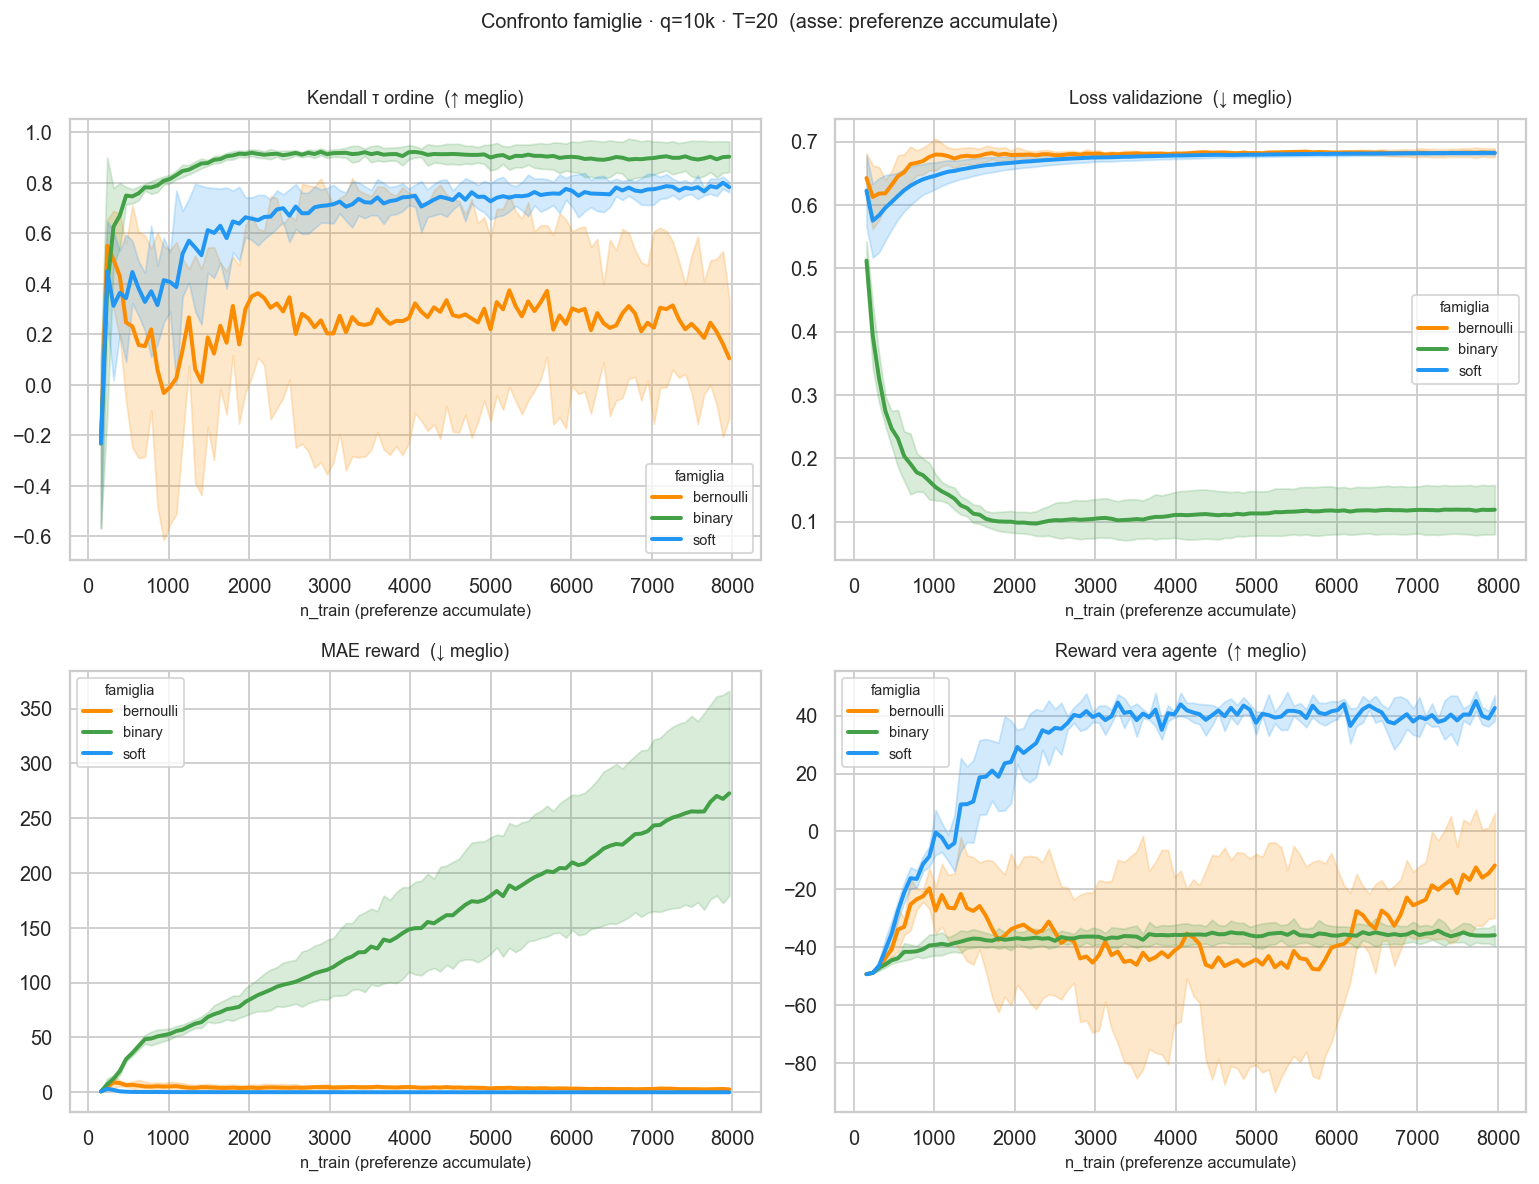

In [26]:
### 1 — Confronto incrociato: tutte le famiglie a q=10k

_FAMILY_PALETTE = {
    "bernoulli": "#FB8C00",
    "binary":    "#43A047",
    "soft":      "#2196F3",
    "baseline":  "#E53935",
}
_Q_COMPARE = 10000  # unico budget comune a tutte e tre le famiglie
_T_COMPARE = 20.0   # temperatura soft (esclude T=5 e T=50)

_cross_mask = (
    (wandb_history["total_queries"] == _Q_COMPARE) &
    (wandb_history["label_family"] != "baseline") &
    (
        (wandb_history["label_family"] != "soft") |
        (np.isclose(wandb_history["temperature"].fillna(_T_COMPARE), _T_COMPARE))
    )
)
_cross_df = wandb_history[_cross_mask].copy()

# Statistiche baseline (agente con true reward): riferimento per rollout/mean_true_reward.
_baseline_df = wandb_history[wandb_history["label_family"] == "baseline"].copy()
_baseline_reward_col = "rollout/mean_true_reward"
if not _baseline_df.empty and _baseline_reward_col in _baseline_df.columns:
    # Usa l'ultimo 20% di timesteps per ogni run (regime stazionario)
    _bl_final = _baseline_df.groupby("wandb_id", group_keys=False).apply(
        lambda g: g.dropna(subset=[_baseline_reward_col]).tail(max(1, len(g) // 5))
    )
    _bl_mean = _bl_final[_baseline_reward_col].mean()
    _bl_std  = _bl_final[_baseline_reward_col].std()
else:
    _bl_mean, _bl_std = np.nan, np.nan

_CROSS_METRICS = [
    ("reward_val/debug_dataset/kendall_running", "Kendall τ ordine  (↑ meglio)"),
    ("reward/loss_all_val",                      "Loss validazione  (↓ meglio)"),
    ("reward_val/debug_dataset/mae_running",     "MAE reward  (↓ meglio)"),
    ("rollout/mean_true_reward",                 "Reward vera agente  (↑ meglio)"),
]
_CROSS_METRICS = [(m, l) for m, l in _CROSS_METRICS if m in _cross_df.columns or m == _baseline_reward_col]

_ncols_c = 2
_nrows_c = math.ceil(len(_CROSS_METRICS) / _ncols_c)

fig_c, axes_c = plt.subplots(_nrows_c, _ncols_c,
                              figsize=(12, 4.5 * _nrows_c), squeeze=False)
fig_c.suptitle(f"Confronto famiglie · q=10k · T=20  (asse: preferenze accumulate)",
               fontsize=11, y=1.01)

for mi, (metric, label) in enumerate(_CROSS_METRICS):
    ax = axes_c[mi // _ncols_c, mi % _ncols_c]
    _plot_df = _cross_df[_cross_df[metric].notna()] if metric in _cross_df.columns else pd.DataFrame()
    if not _plot_df.empty:
        sns.lineplot(
            data=_plot_df, x="dataset/n_train", y=metric,
            hue="label_family",
            hue_order=[f for f in ["bernoulli", "binary", "soft"] if f in _plot_df["label_family"].unique()],
            palette=_FAMILY_PALETTE,
            estimator="mean", errorbar="sd",
            linewidth=2.2, ax=ax,
        )
    # Linea di riferimento baseline (solo per rollout/mean_true_reward)
    if metric == _baseline_reward_col and not np.isnan(_bl_mean):
        ax.axhline(_bl_mean, color=_FAMILY_PALETTE["baseline"],
                   linestyle="--", linewidth=1.8, zorder=5, label="baseline (PPO true reward)")
        ax.fill_between(ax.get_xlim(),
                        _bl_mean - _bl_std, _bl_mean + _bl_std,
                        color=_FAMILY_PALETTE["baseline"], alpha=0.12)
        ax.legend(fontsize=8, title_fontsize=8)
    ax.set_title(label, fontsize=10, pad=8)
    ax.set_xlabel("n_train (preferenze accumulate)", fontsize=9)
    ax.set_ylabel("")
    if not _plot_df.empty:
        handles, lbl_handles = ax.get_legend_handles_labels()
        ax.legend(handles, lbl_handles, title="famiglia", fontsize=8, title_fontsize=8)

for idx in range(len(_CROSS_METRICS), _nrows_c * _ncols_c):
    axes_c.flat[idx].set_visible(False)

plt.tight_layout()
plt.savefig(EXPERIMENT_ROOT / "analysis_tables" / "wandb_crossfamily_comparison.png",
            bbox_inches="tight", dpi=150)
plt.show()


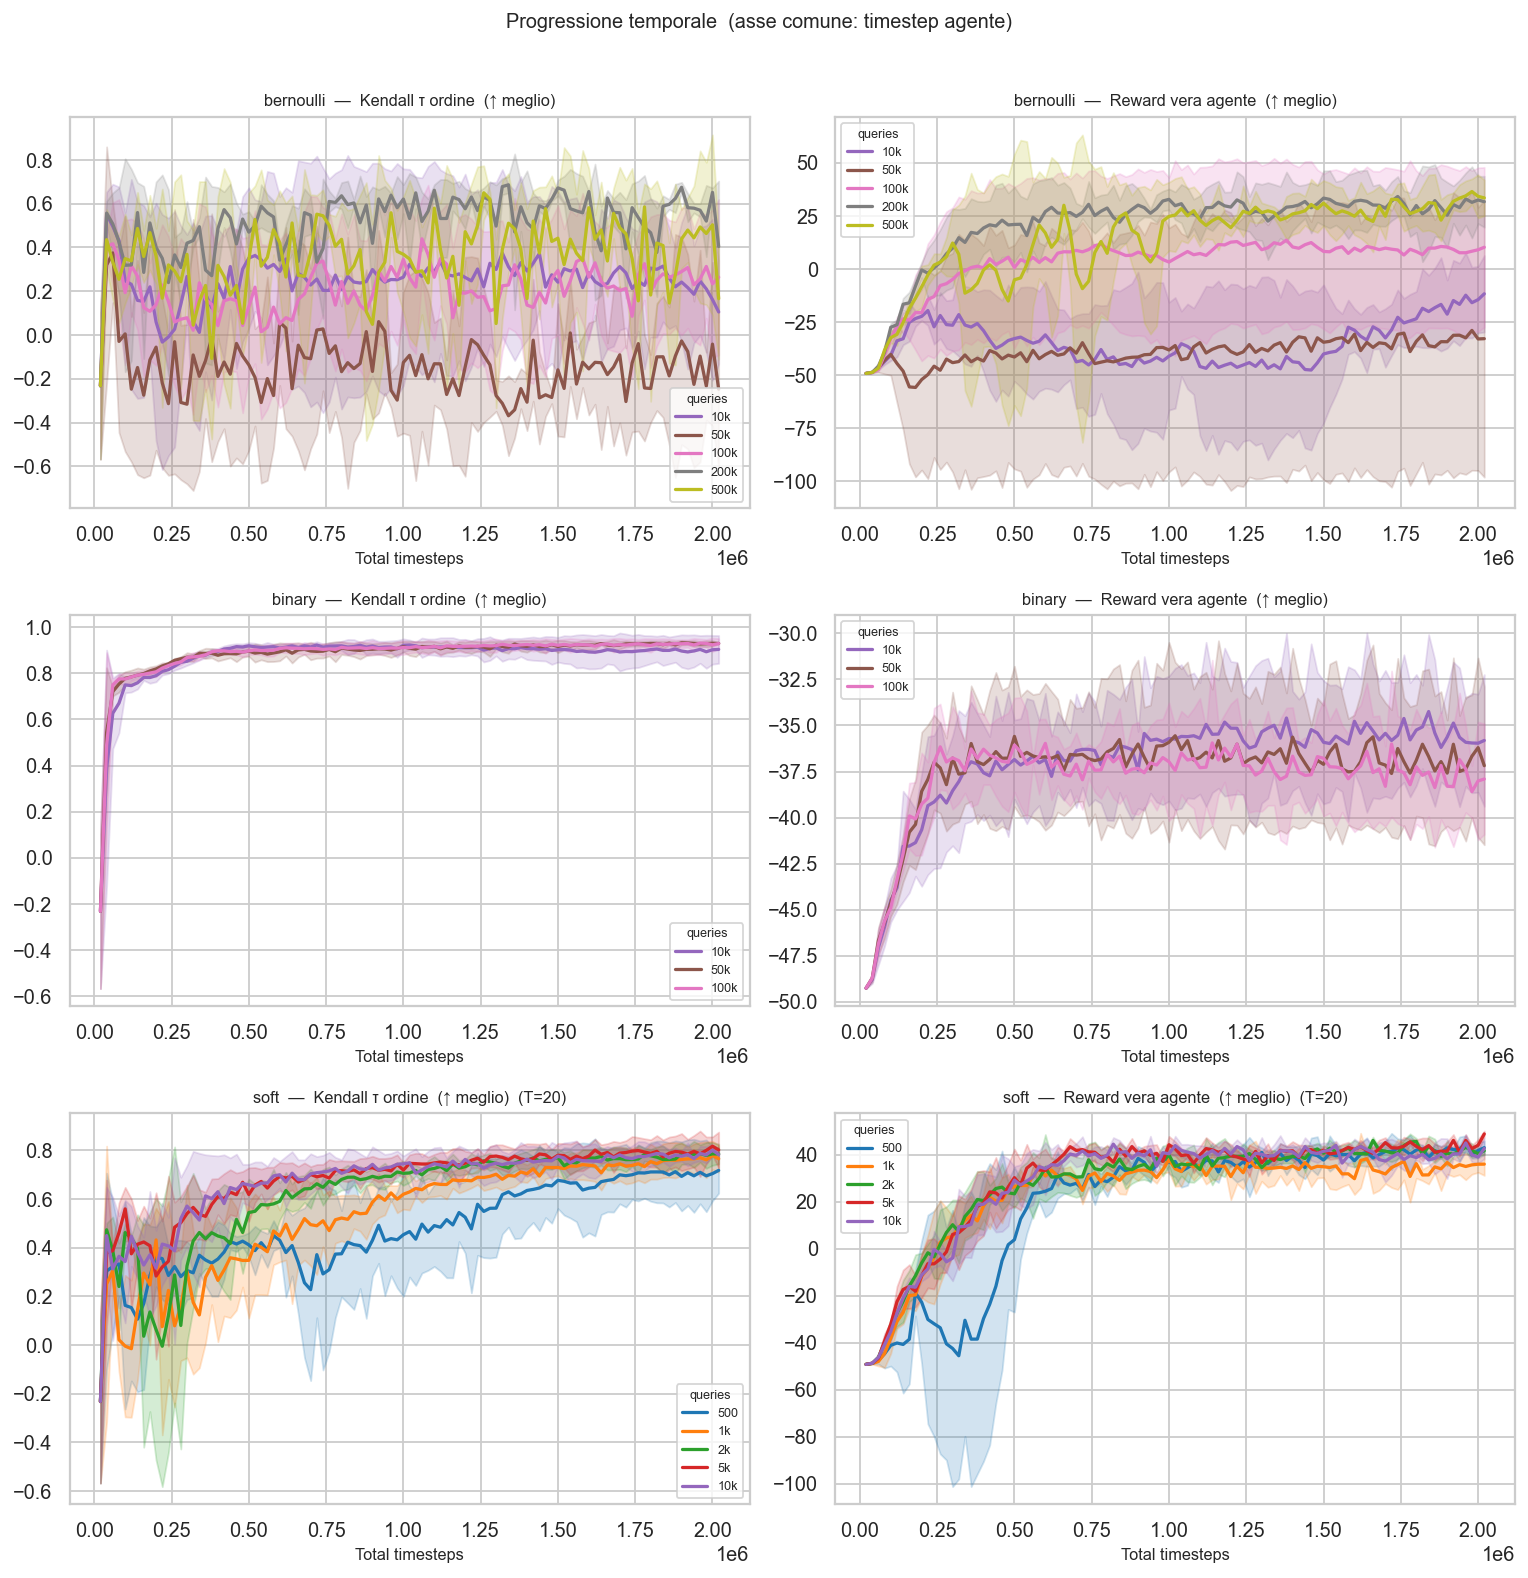

In [28]:
### 2 — Progressione temporale per famiglia (asse: timestep agente)

_TS_METRICS = [
    ("reward_val/debug_dataset/kendall_running", "Kendall τ ordine  (↑ meglio)"),
    ("rollout/mean_true_reward",                 "Reward vera agente  (↑ meglio)"),
]
_TS_METRICS = [(m, l) for m, l in _TS_METRICS if m in wandb_history.columns]

# Palette queries condivisa con le curve di apprendimento locali
_ts_all_q = sorted(wandb_history["total_queries"].dropna().unique())
_TS_Q_PALETTE = dict(zip(
    _ts_all_q,
    sns.color_palette("tab10", len(_ts_all_q)) if len(_ts_all_q) <= 10
    else sns.color_palette("viridis", len(_ts_all_q)),
))
_ts_q_fmt = lambda q: f"{int(q)//1000}k" if q >= 1000 else str(int(q))

_families_ts = sorted(wandb_history["label_family"].dropna().unique())
_nrows_ts = len(_families_ts)
_ncols_ts = len(_TS_METRICS)

fig_ts, axes_ts = plt.subplots(_nrows_ts, _ncols_ts,
                                figsize=(6 * _ncols_ts, 4 * _nrows_ts), squeeze=False)
fig_ts.suptitle("Progressione temporale  (asse comune: timestep agente)",
                fontsize=11, y=1.01)

for r, family in enumerate(_families_ts):
    fam_df = wandb_history[wandb_history["label_family"] == family].copy()

    if family == "baseline":
        hue_col, hue_title = "seed", "seed"
        _seeds = sorted(fam_df["seed"].dropna().unique())
        _hue_palette = dict(zip(_seeds, sns.color_palette("Set2", len(_seeds))))
        _hue_order = _seeds
        _fmt_lbl = lambda l: l
    elif family == "soft":
        # Filtra alla temperatura di riferimento per evitare sovrapposizioni
        _avail = fam_df["temperature"].dropna().unique()
        _t_ref = _SOFT_T_REF if _SOFT_T_REF in _avail else sorted(_avail)[len(_avail)//2]
        fam_df = fam_df[np.isclose(fam_df["temperature"].fillna(-1), _t_ref)]
        hue_col, hue_title = "total_queries", "queries"
        _fam_q = sorted(fam_df["total_queries"].dropna().unique())
        _hue_palette = {q: _TS_Q_PALETTE[q] for q in _fam_q if q in _TS_Q_PALETTE}
        _hue_order = _fam_q
        _fmt_lbl = lambda l: _ts_q_fmt(float(l)) if l.replace('.','').isdigit() else l
    else:
        hue_col, hue_title = "total_queries", "queries"
        _fam_q = sorted(fam_df["total_queries"].dropna().unique())
        _hue_palette = {q: _TS_Q_PALETTE[q] for q in _fam_q if q in _TS_Q_PALETTE}
        _hue_order = _fam_q
        _fmt_lbl = lambda l: _ts_q_fmt(float(l)) if l.replace('.','').isdigit() else l

    for c, (metric, label) in enumerate(_TS_METRICS):
        ax = axes_ts[r, c]
        _plot_df = fam_df.dropna(subset=[metric])
        if _plot_df.empty:
            ax.text(0.5, 0.5, "n/a", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10, color="gray")
            ax.set_title(f"{family}  —  {label}", fontsize=9, pad=6)
            continue

        _valid_order = [h for h in _hue_order if h in _plot_df[hue_col].values]
        sns.lineplot(
            data=_plot_df, x="agent/time/total_timesteps", y=metric,
            hue=hue_col, hue_order=_valid_order,
            palette=_hue_palette,
            estimator="mean", errorbar="sd",
            linewidth=1.8, ax=ax,
        )
        title = f"{family}  —  {label}"
        if family == "soft":
            title += f"  (T={int(_t_ref)})"
        ax.set_title(title, fontsize=9, pad=6)
        ax.set_xlabel("Total timesteps", fontsize=9)
        ax.set_ylabel("")
        handles, lbls = ax.get_legend_handles_labels()
        ax.legend(handles, [_fmt_lbl(l) for l in lbls],
                  title=hue_title, fontsize=7, title_fontsize=7)

plt.tight_layout()
plt.savefig(EXPERIMENT_ROOT / "analysis_tables" / "wandb_temporal_curves.png",
            bbox_inches="tight", dpi=150)
plt.show()


## Confronto finale per query budget

Qui confrontiamo solo l'ultimo checkpoint di ogni run. Questo è il grafico più diretto per sostenere:

- binary non ricostruisce la reward esatta;
- Bernoulli migliora solo aumentando molto le query;
- soft labels raggiunge errore basso con meno query.

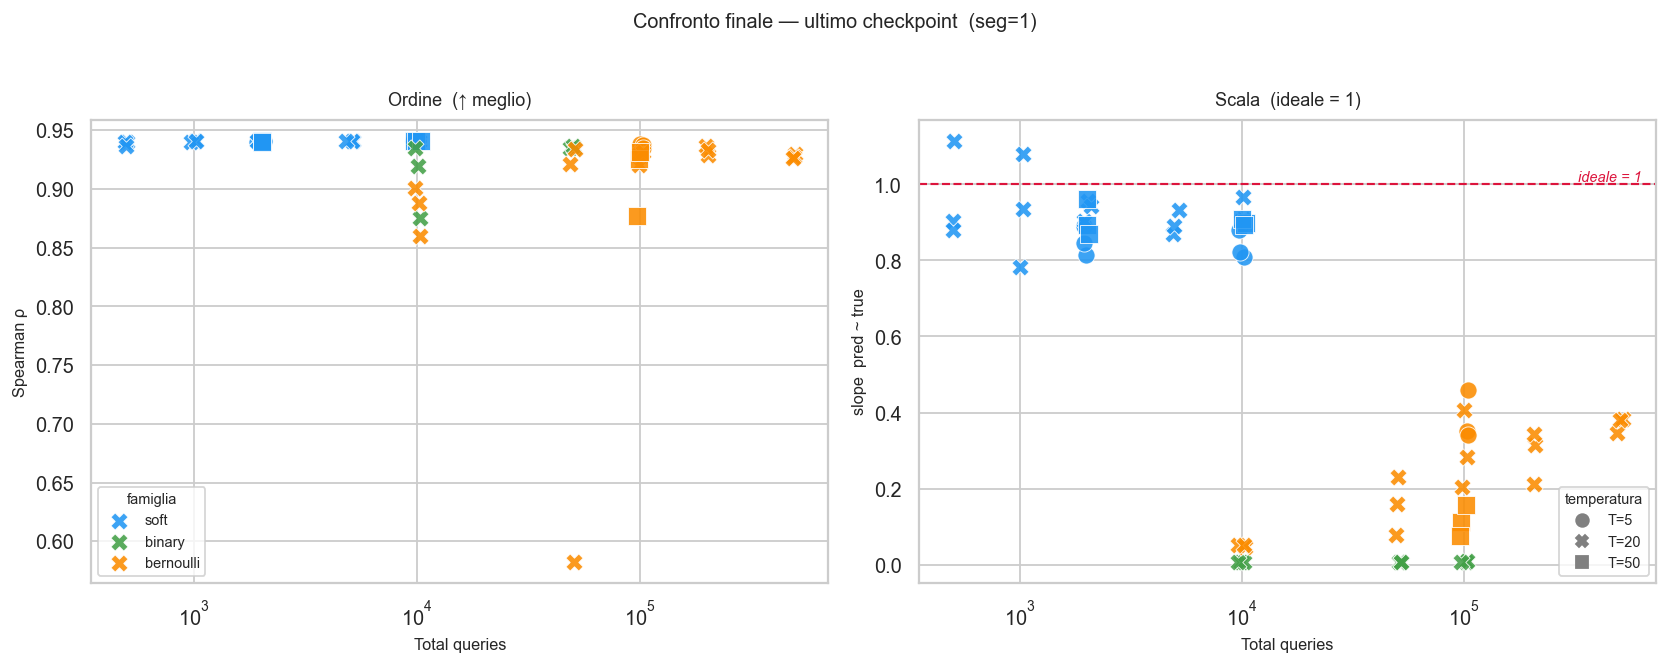

,run_name,label_family,total_queries,temperature,seed,checkpoint,spearman,bisector_slope
27,ppo_chri_binary_bernoulli seg=1 q=10000 temp=2...,bernoulli,10000,20.0,0,100,0.859670,0.051894
57,ppo_chri_binary_bernoulli seg=1 q=10000 temp=2...,bernoulli,10000,20.0,1,100,0.901210,0.051417
87,ppo_chri_binary_bernoulli seg=1 q=10000 temp=2...,bernoulli,10000,20.0,2,100,0.887912,0.047516
117,ppo_chri_binary_bernoulli seg=1 q=50000 temp=2...,bernoulli,50000,20.0,0,100,0.934052,0.159527
147,ppo_chri_binary_bernoulli seg=1 q=50000 temp=2...,bernoulli,50000,20.0,1,100,0.920989,0.230759
...,...,...,...,...,...,...,...,...
2217,ppo_chri_soft seg=1 q=10000 temp=30 seed=1 sof...,soft,10000,30.0,1,100,0.940469,0.906192
2247,ppo_chri_soft seg=1 q=10000 temp=30 seed=2 sof...,soft,10000,30.0,2,100,0.940465,0.904472
2277,ppo_chri_soft seg=1 q=10000 temp=50 seed=0 sof...,soft,10000,50.0,0,100,0.940394,0.899264
2307,ppo_chri_soft seg=1 q=10000 temp=50 seed=1 sof...,soft,10000,50.0,1,100,0.940513,0.909592


In [ ]:
final_metrics = (
    metrics.sort_values("checkpoint")
    .groupby(["run_name", "segment_length"], as_index=False)
    .tail(1)
    .copy()
)

seg1_final = final_metrics[final_metrics["segment_length"] == 1].copy()

FAMILY_PALETTE = {"soft": "#2196F3", "binary": "#43A047", "bernoulli": "#FB8C00"}
FAMILY_ORDER   = ["soft", "binary", "bernoulli"]
TEMP_MARKERS   = {5.0: "o", 20.0: "X", 50.0: "s"}
q_fmt          = lambda q: f"{int(q)//1000}k" if pd.notna(q) and q >= 1000 else str(int(q))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confronto finale — ultimo checkpoint  (seg=1)", fontsize=11, y=1.02)

panels = [
    ("spearman",       "Spearman ρ",         None, "Ordine  (↑ meglio)"),
    ("ols_slope", "slope  pred ~ true",  1.0,  "Scala  (ideale = 1)"),
]

rng = np.random.default_rng(0)

for ax, (metric, ylabel, ref, title) in zip(axes, panels):
    for family in FAMILY_ORDER:
        sub = seg1_final[seg1_final["label_family"] == family]
        if sub.empty:
            continue
        for temp, marker in TEMP_MARKERS.items():
            pts = sub[np.isclose(sub["temperature"], temp)] if pd.notna(temp) else sub
            if pts.empty:
                continue
            # jitter logaritmico sull'asse X per separare punti sovrapposti
            x_jitter = pts["total_queries"] * (1 + rng.uniform(-0.04, 0.04, len(pts)))
            label = family if temp == 20.0 else None
            ax.scatter(x_jitter, pts[metric],
                       color=FAMILY_PALETTE[family], marker=marker,
                       s=90, alpha=0.88, edgecolors="white", linewidths=0.5,
                       label=label, zorder=3)

    if ref is not None:
        ax.axhline(ref, color="crimson", linestyle="--", linewidth=1.2, zorder=1)
        ax.annotate("ideale = 1", xy=(0.98, 1.0), xycoords=("axes fraction", "data"),
                    ha="right", va="bottom", fontsize=8, color="crimson", fontstyle="italic")

    ax.set_xscale("log")
    ax.set_title(title, fontsize=10, pad=8)
    ax.set_xlabel("Total queries", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(title="famiglia", fontsize=8, title_fontsize=8)

# Legenda marker temperatura (comune)
from matplotlib.lines import Line2D
temp_handles = [
    Line2D([0], [0], marker=m, color="gray", linestyle="None",
           markersize=7, label=f"T={int(t)}")
    for t, m in TEMP_MARKERS.items()
]
axes[1].legend(handles=temp_handles, title="temperatura", fontsize=8, title_fontsize=8,
               loc="lower right")

plt.tight_layout()
plt.savefig(EXPERIMENT_ROOT / "analysis_tables" / "final_comparison_scatter.png",
            bbox_inches="tight", dpi=150)
plt.show()

seg1_final.sort_values(["label_family", "total_queries", "temperature", "seed"])[
    ["run_name", "label_family", "total_queries", "temperature", "seed", "checkpoint",
     "spearman", "ols_slope"]
]


## Scatter plot: reward vera vs reward predetta

Questa è la figura più importante per la discussione qualitativa. Ogni pannello usa l'ultimo checkpoint disponibile per una run rappresentativa.

Se i punti sono vicini alla linea rossa `y=x`, il reward model sta ricostruendo bene la reward function, non solo l'ordine delle preferenze.

In [ ]:
def select_representative_runs(final_df):
    """Per ogni configurazione distinta (family, queries, temperature) prende il seed mediano per RMSE."""
    candidates = []
    groups = final_df.groupby(["label_family", "total_queries", "temperature"], dropna=False)
    for _, group in groups:
        sub = group.sort_values("rmse")
        candidates.append(sub.iloc[len(sub) // 2])
    return pd.DataFrame(candidates)


scatter_runs = select_representative_runs(seg1_final)
scatter_runs[["run_name", "label_family", "total_queries", "temperature", "seed", "rmse", "spearman", "ols_slope"]]


,run_name,label_family,total_queries,temperature,seed,rmse,spearman,bisector_slope
57,ppo_chri_binary_bernoulli seg=1 q=10000 temp=2...,bernoulli,10000,20.0,1,31.092820,0.901210,0.051417
117,ppo_chri_binary_bernoulli seg=1 q=50000 temp=2...,bernoulli,50000,20.0,0,26.960509,0.934052,0.159527
267,ppo_chri_binary_bernoulli seg=1 q=100000 temp=...,bernoulli,100000,5.0,2,21.199127,0.938144,0.351560
327,ppo_chri_binary_bernoulli seg=1 q=100000 temp=...,bernoulli,100000,10.0,1,20.957762,0.933001,0.344274
387,ppo_chri_binary_bernoulli seg=1 q=100000 temp=...,bernoulli,100000,20.0,0,22.913745,0.931051,0.283260
537,ppo_chri_binary_bernoulli seg=1 q=100000 temp=...,bernoulli,100000,50.0,2,28.716304,0.925241,0.111038
627,ppo_chri_binary_bernoulli seg=1 q=200000 temp=...,bernoulli,200000,20.0,2,21.798681,0.929175,0.313687
687,ppo_chri_binary_bernoulli seg=1 q=500000 temp=...,bernoulli,500000,20.0,1,20.124208,0.927436,0.382943
747,ppo_chri_binary seg=1 q=10000 temp=20 seed=0 d...,binary,10000,20.0,0,32.748007,0.875472,0.006403
837,ppo_chri_binary seg=1 q=50000 temp=20 seed=0 d...,binary,50000,20.0,0,32.717072,0.936176,0.007837


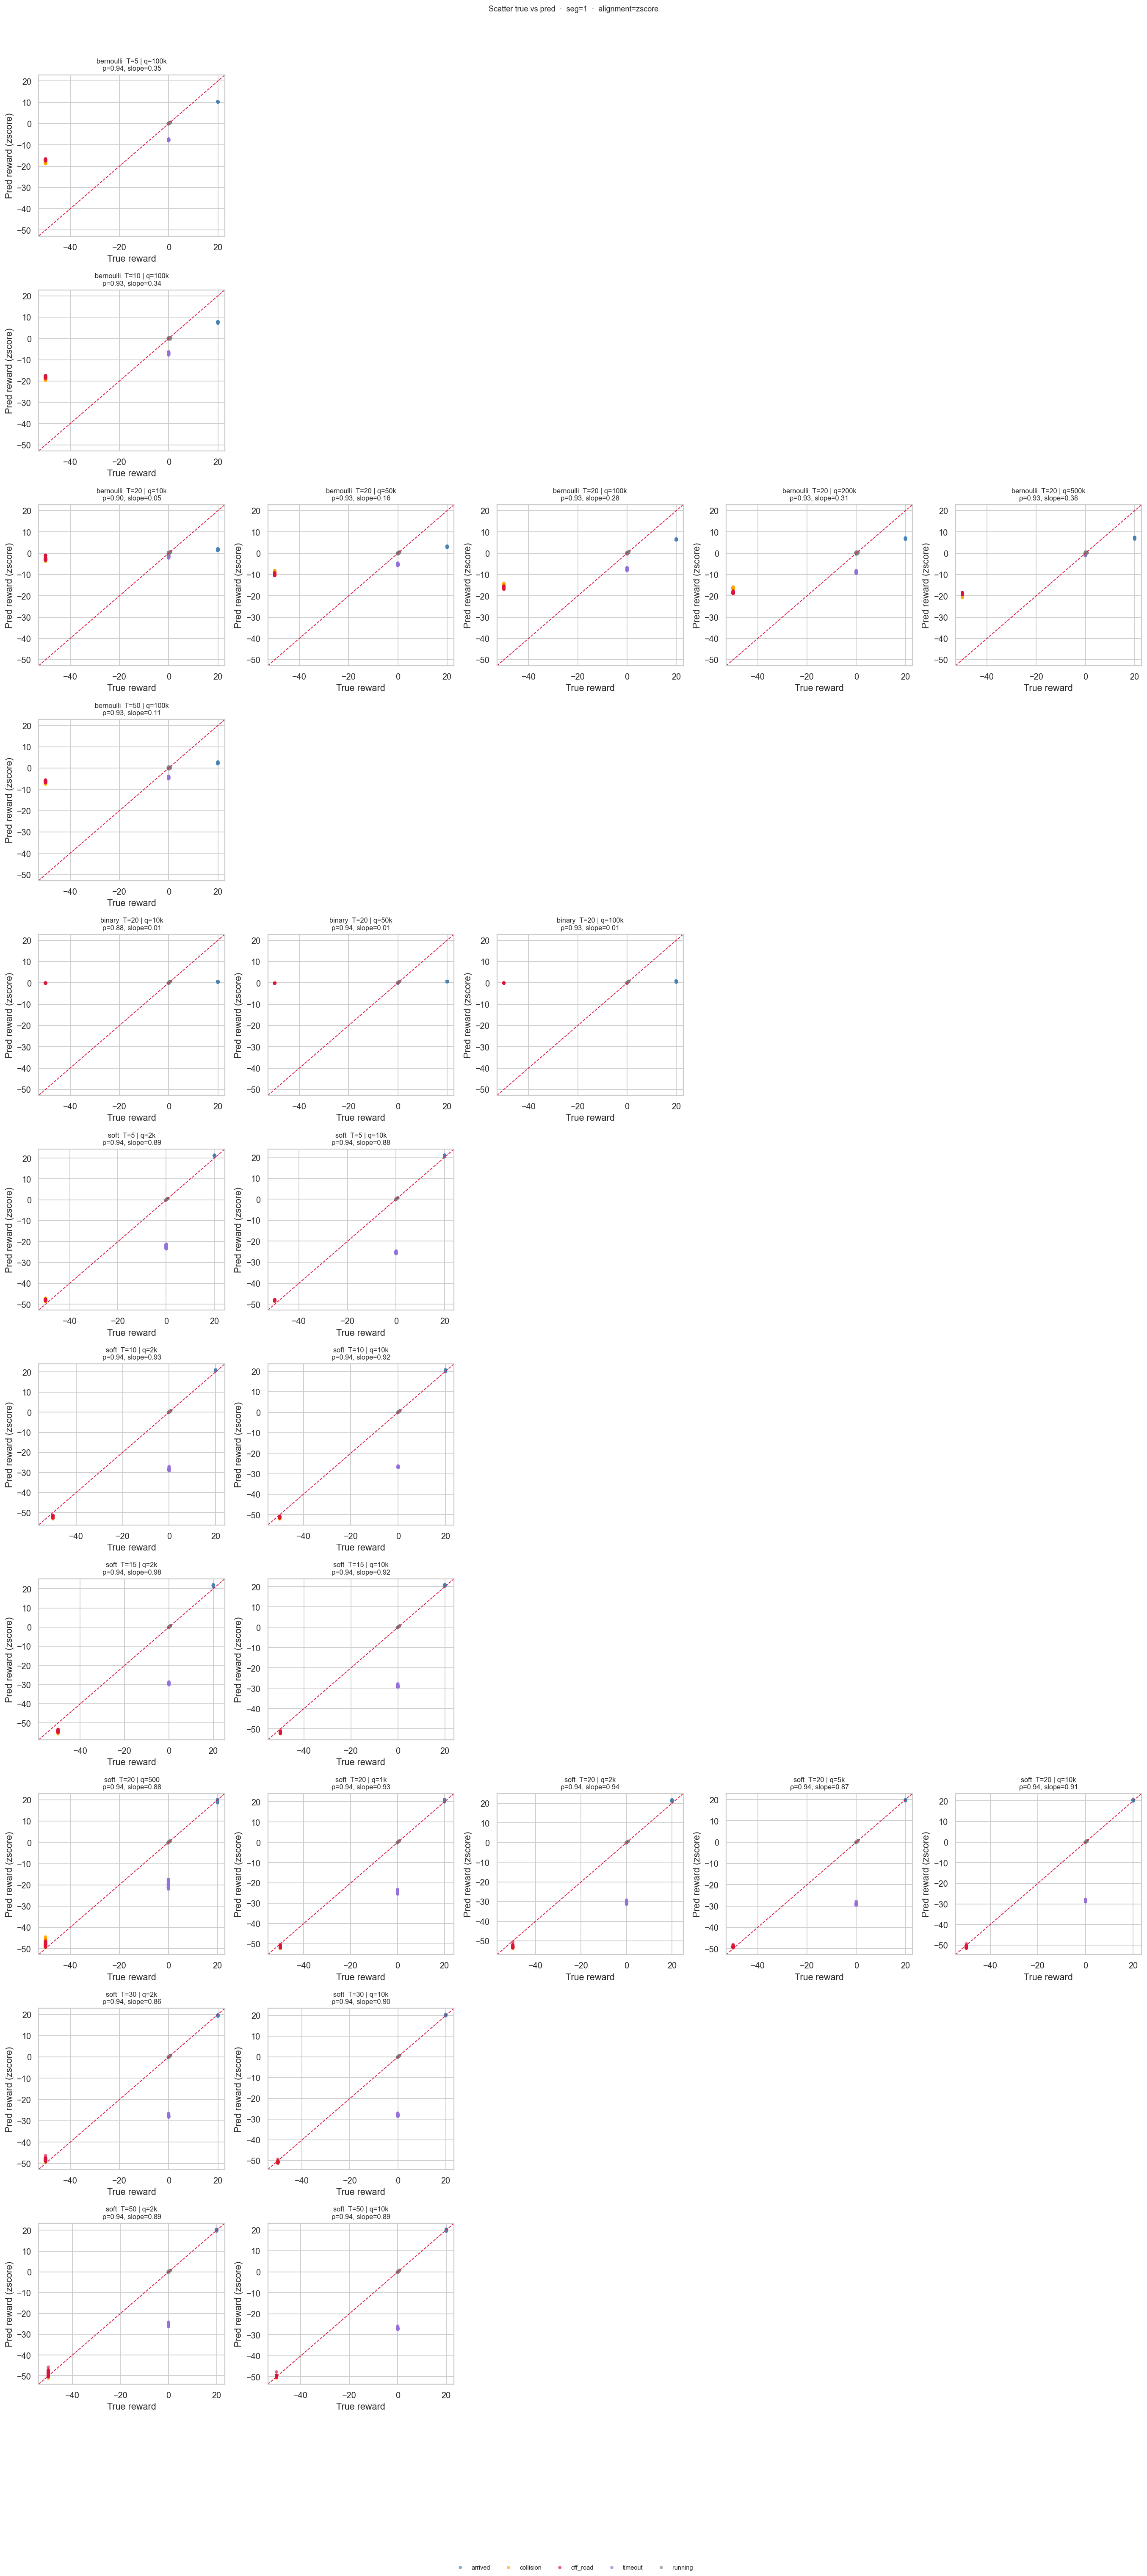

In [ ]:
STATUS_COLORS = {
    0: "steelblue", 1: "orange", 2: "crimson", 3: "mediumpurple",
    4: "gray", 5: "gold", 6: "saddlebrown",
}

_q_str = lambda q: f"{int(q)//1000}k" if q >= 1000 else str(int(q))


def draw_scatter(ax, df, title):
    for status_id, color in STATUS_COLORS.items():
        mask = df["status"] == status_id
        if not mask.any():
            continue
        ax.scatter(
            df.loc[mask, "true"], df.loc[mask, "pred"],
            s=18, alpha=0.65, edgecolors="none", color=color,
            label=STATUS_LABELS.get(status_id, str(status_id)),
        )
    lo = min(df["true"].min(), df["pred"].min())
    hi = max(df["true"].max(), df["pred"].max())
    pad = 0.04 * (hi - lo + 1e-8)
    lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("True reward")
    ax.set_ylabel(f"Pred reward ({ALIGNMENT})")


def plot_scatter_grid(sc_runs, seg_len):
    """Una riga per (label_family, temperature), colonne = query budget della riga."""
    row_keys = (
        sc_runs
        .assign(_temp_sort=sc_runs["temperature"].fillna(-1))
        .sort_values(["label_family", "_temp_sort"])
        [["label_family", "temperature"]]
        .drop_duplicates()
        .values.tolist()
    )

    ncols_max = max(
        len(sc_runs[
            (sc_runs["label_family"] == fam) &
            (np.isclose(sc_runs["temperature"].fillna(-1), temp) if pd.notna(temp) else True)
        ]["total_queries"].dropna().unique())
        for fam, temp in row_keys
    )

    nrows = len(row_keys)
    fig, axes = plt.subplots(nrows, ncols_max,
                             figsize=(4.2 * ncols_max, 4.2 * nrows), squeeze=False)
    fig.suptitle(f"Scatter true vs pred  ·  seg={seg_len}  ·  alignment={ALIGNMENT}",
                 fontsize=10, y=1.01)

    for r, (family, temp) in enumerate(row_keys):
        row_label = family if pd.isna(temp) else f"{family}  T={temp:g}"
        mask_row = sc_runs["label_family"] == family
        if pd.notna(temp):
            mask_row &= np.isclose(sc_runs["temperature"].fillna(-1), temp)
        row_runs = sc_runs[mask_row].sort_values("total_queries").reset_index(drop=True)

        for c in range(ncols_max):
            ax = axes[r, c]
            if c >= len(row_runs):
                ax.set_visible(False)
                continue
            run = row_runs.iloc[c]
            key = (str(run["run_dir"]), int(run["checkpoint"]), seg_len)
            df = score_cache[key]
            title = (
                f"{row_label} | q={_q_str(run['total_queries'])}\n"
                f"ρ={run['spearman']:.2f}, slope={run['ols_slope']:.2f}"
            )
            draw_scatter(ax, df, title)

    handles, labels = next(
        (axes[r, c].get_legend_handles_labels()
         for r in range(nrows) for c in range(ncols_max)
         if axes[r, c].get_visible() and axes[r, c].get_legend_handles_labels()[0]),
        ([], [])
    )
    fig.legend(handles, labels, loc="lower center",
               ncol=min(len(labels), 7), fontsize=8, frameon=False)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


# seg_len = 1 (per-step)
plot_scatter_grid(scatter_runs, seg_len=1)


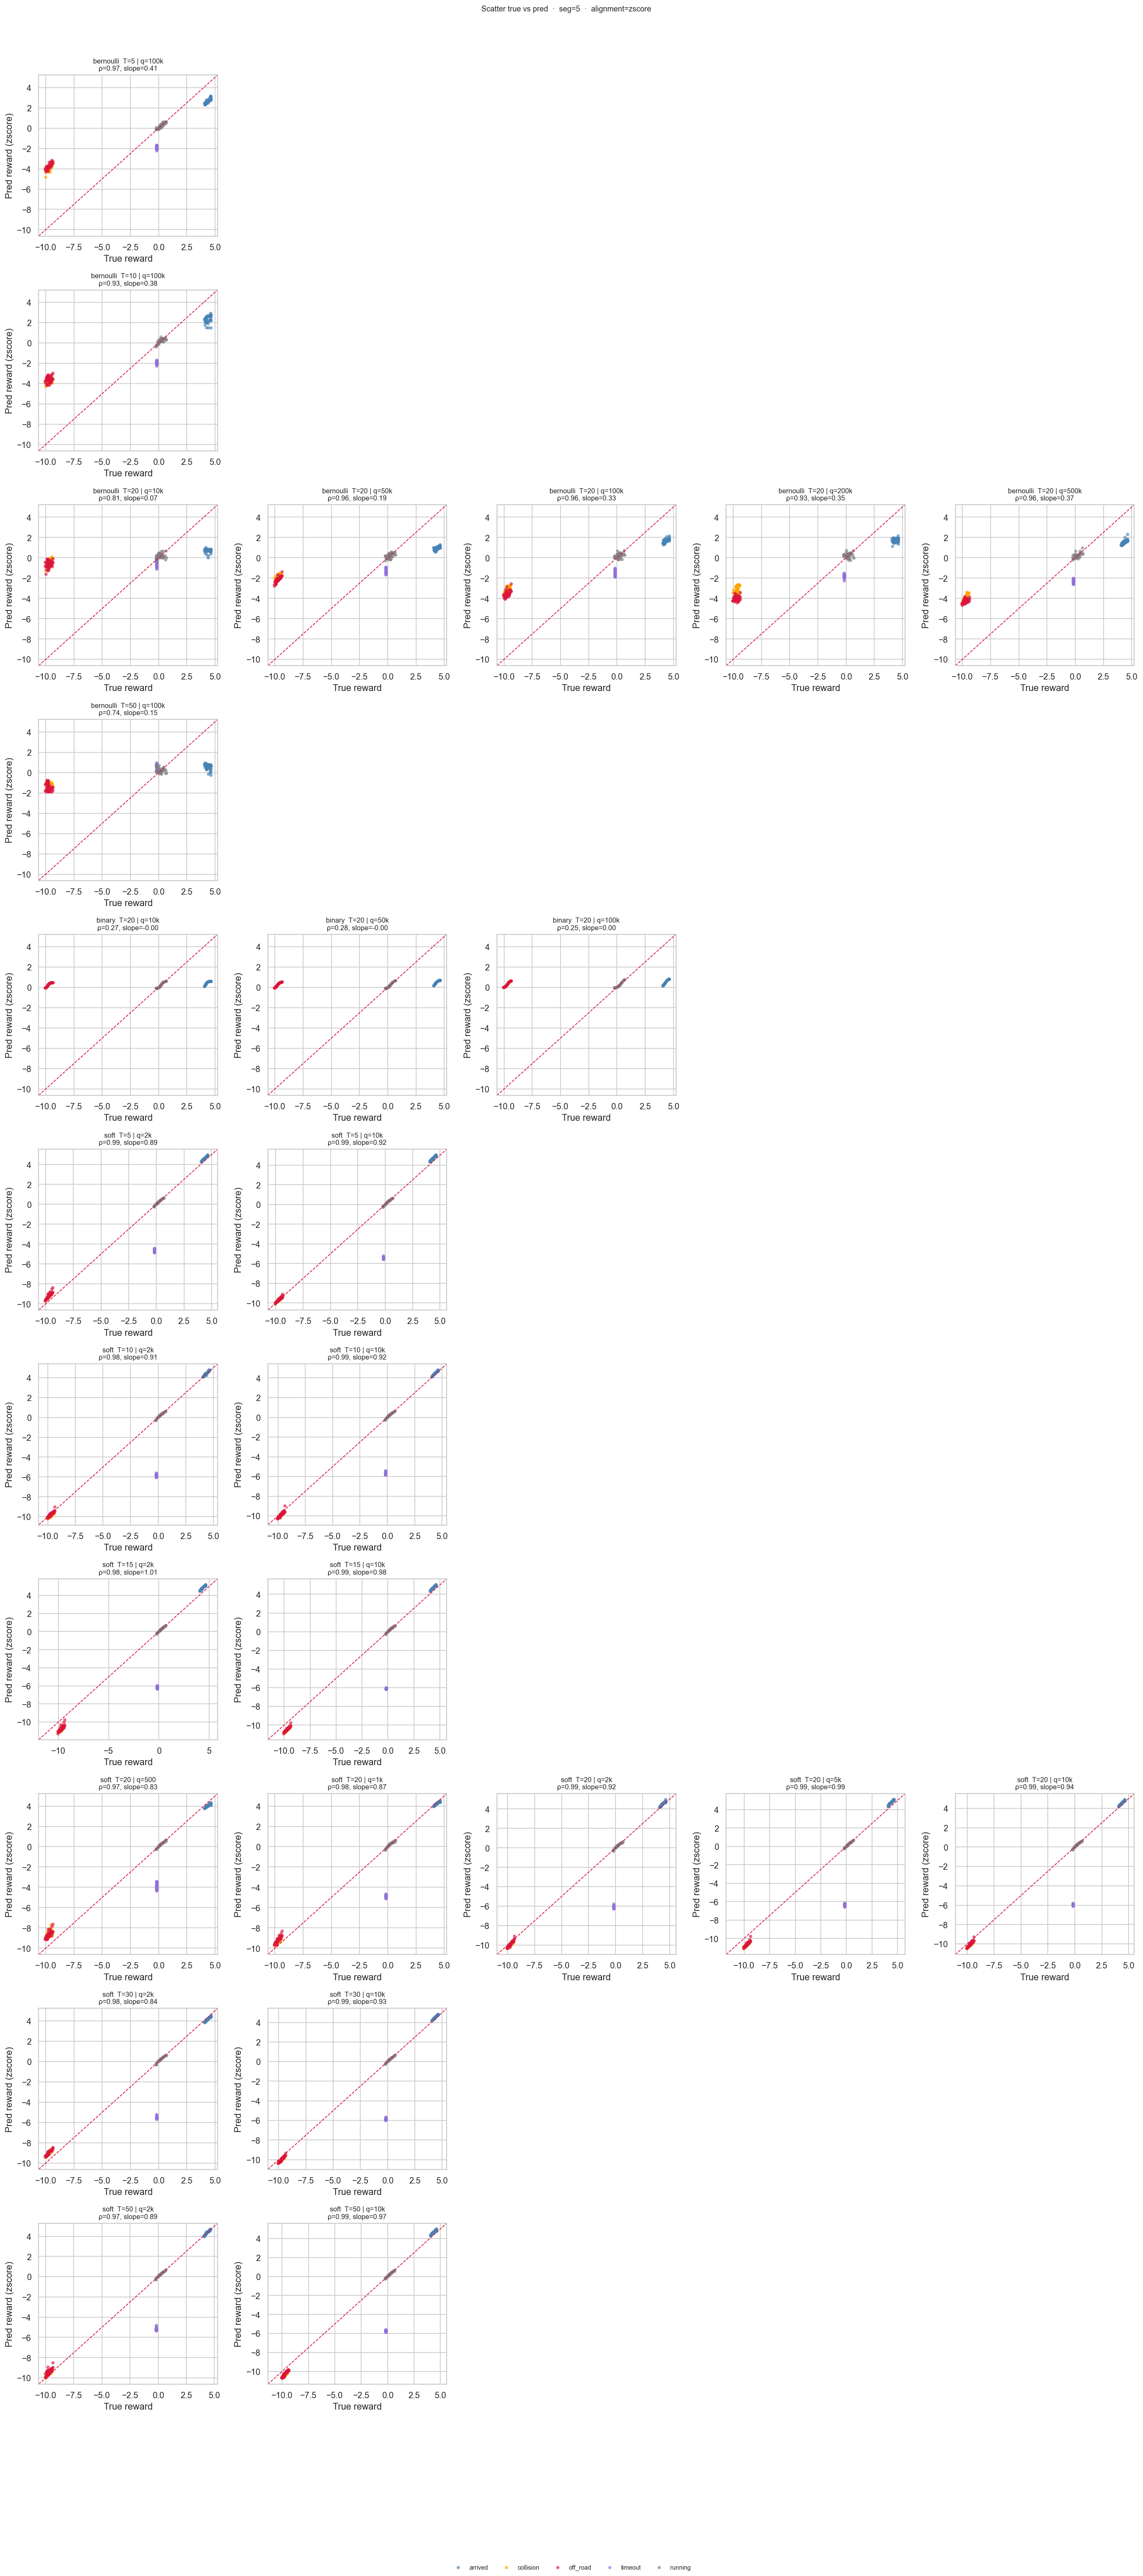

In [39]:
seg5_final = final_metrics[final_metrics["segment_length"] == 5].copy()
scatter_runs_5 = select_representative_runs(seg5_final)
plot_scatter_grid(scatter_runs_5, seg_len=5)


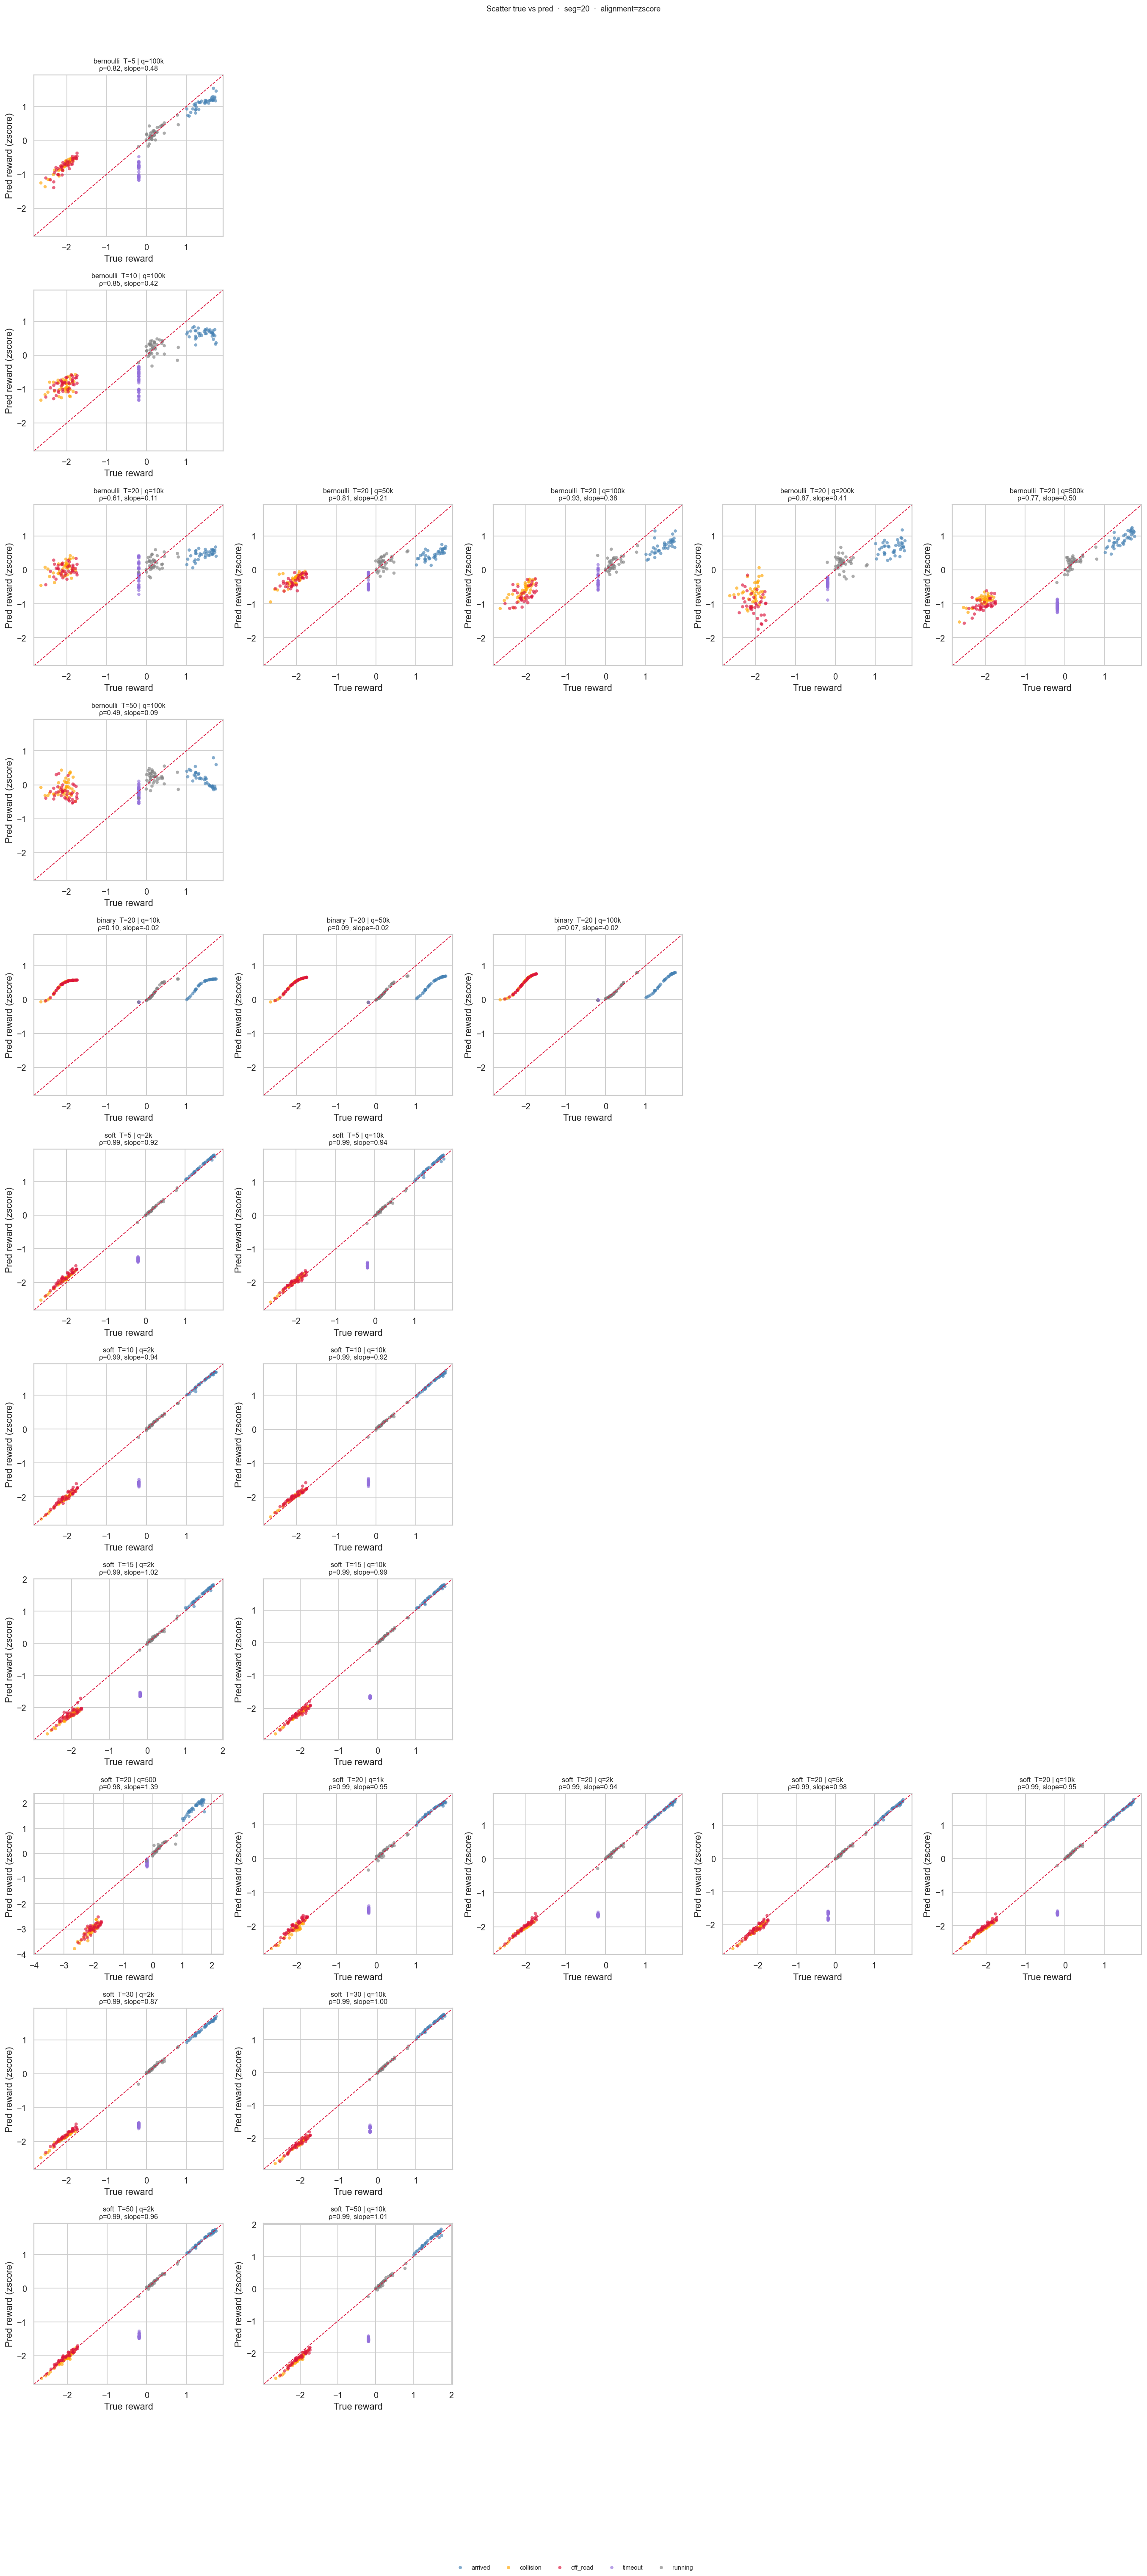

In [40]:
seg20_final = final_metrics[final_metrics["segment_length"] == 20].copy()
scatter_runs_20 = select_representative_runs(seg20_final)
plot_scatter_grid(scatter_runs_20, seg_len=20)


In [ ]:
ep_final = final_metrics[final_metrics["segment_length"] == "episode"].copy()
if ep_final.empty:
    print("Episodi non presenti nel dataset di eval — esegui prima la cella di accodata in create_balanced_eval_set.ipynb")
else:
    scatter_runs_ep = select_representative_runs(ep_final)
    plot_scatter_grid(scatter_runs_ep, seg_len="episode")


## Effetto della temperatura sulle soft labels

Questo isola la scelta della temperatura. Una temperatura troppo bassa rende le soft labels quasi binarie; una troppo alta comprime troppo le differenze. La temperatura buona dovrebbe dare RMSE più basso e slope più vicino a 1.

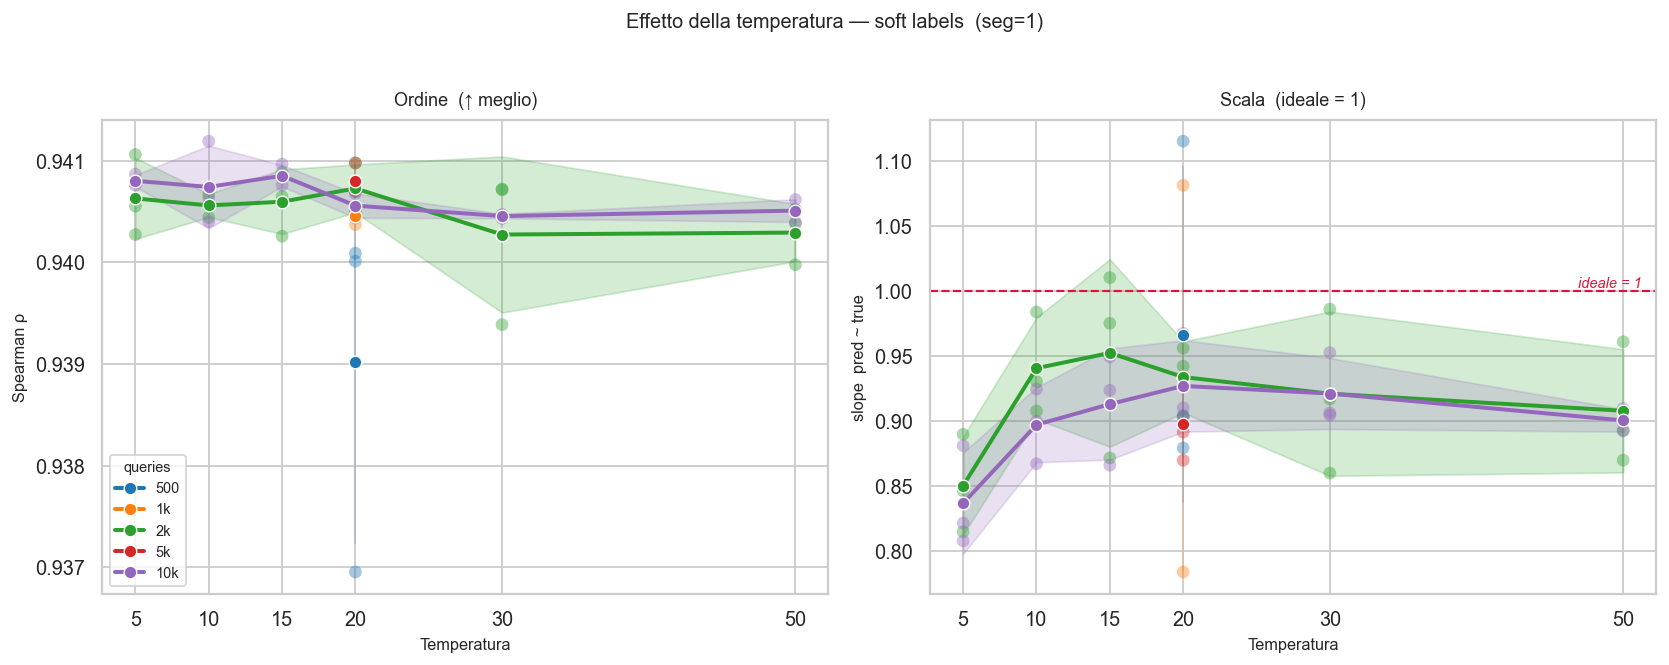

In [ ]:
soft_final = seg1_final[seg1_final["label_family"] == "soft"].copy()

if soft_final.empty:
    print("Nessuna run soft trovata.")
else:
    query_vals = sorted(soft_final["total_queries"].dropna().unique())
    palette    = dict(zip(query_vals, sns.color_palette("tab10", len(query_vals))))
    q_fmt      = lambda q: f"{int(q)//1000}k" if q >= 1000 else str(int(q))
    temp_vals  = sorted(soft_final["temperature"].dropna().unique())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Effetto della temperatura — soft labels  (seg=1)", fontsize=11, y=1.02)

    panels = [
        ("spearman",       "Spearman ρ",         None, "Ordine  (↑ meglio)"),
        ("ols_slope", "slope  pred ~ true",  1.0,  "Scala  (ideale = 1)"),
    ]

    for ax, (metric, ylabel, ref, title) in zip(axes, panels):
        # Punti individuali per seed (semi-trasparenti)
        for q in query_vals:
            sub = soft_final[soft_final["total_queries"] == q]
            ax.scatter(sub["temperature"], sub[metric],
                       color=palette[q], alpha=0.4, s=50, zorder=2, edgecolors="none")

        # Linea media ± sd
        sns.lineplot(
            data=soft_final, x="temperature", y=metric,
            hue="total_queries", palette=palette,
            estimator="mean", errorbar="sd",
            marker="o", markersize=7, linewidth=2.2, ax=ax,
            legend=(ax is axes[0]),
        )

        if ref is not None:
            ax.axhline(ref, color="crimson", linestyle="--", linewidth=1.2, zorder=1)
            ax.annotate("ideale = 1", xy=(0.98, 1.0), xycoords=("axes fraction", "data"),
                        ha="right", va="bottom", fontsize=8, color="crimson", fontstyle="italic")

        ax.set_title(title, fontsize=10, pad=8)
        ax.set_xlabel("Temperatura", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xticks(temp_vals)
        ax.set_xticklabels([str(int(t)) for t in temp_vals])

    # Legenda con etichette formattate
    handles, lbls = axes[0].get_legend_handles_labels()
    axes[0].legend(
        handles, [q_fmt(float(l)) if l.replace(".", "").isdigit() else l for l in lbls],
        title="queries", fontsize=8, title_fontsize=8,
    )

    plt.tight_layout()
    plt.savefig(EXPERIMENT_ROOT / "analysis_tables" / "temperature_effect.png",
                bbox_inches="tight", dpi=150)
    plt.show()


## Tabella riassuntiva

Questa tabella aggrega sull'ultimo checkpoint

In [ ]:
summary = (
    seg1_final
    .groupby(["label_family", "total_queries", "temperature"], dropna=False)
    .agg(
        n_runs=("run_name", "nunique"),
        spearman_mean=("spearman", "mean"),
        spearman_std=("spearman", "std"),
        slope_mean=("ols_slope", "mean"),
        slope_std=("ols_slope", "std"),
    )
    .reset_index()
    .sort_values(["label_family", "total_queries", "temperature"])
)
summary


,label_family,total_queries,temperature,n_runs,spearman_mean,spearman_std,slope_mean,slope_std
0,bernoulli,10000,20.0,3,0.882931,0.021213,0.050276,0.002402
1,bernoulli,50000,20.0,3,0.812457,0.199403,0.155803,0.076886
2,bernoulli,100000,5.0,3,0.936903,0.001486,0.384057,0.065939
3,bernoulli,100000,10.0,3,0.934382,0.002068,0.367340,0.131670
4,bernoulli,100000,20.0,3,0.927073,0.005637,0.298489,0.102271
5,bernoulli,100000,50.0,3,0.911228,0.029907,0.114151,0.041450
6,bernoulli,200000,20.0,3,0.932728,0.003508,0.289656,0.068776
7,bernoulli,500000,20.0,3,0.927897,0.001988,0.370037,0.020139
8,binary,10000,20.0,3,0.909950,0.030852,0.006777,0.000422
9,binary,50000,20.0,3,0.935423,0.000654,0.007485,0.000420


In [36]:
EXPORT_DIR = EXPERIMENT_ROOT / "analysis_tables"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
metrics.to_csv(EXPORT_DIR / "checkpoint_metrics_all.csv", index=False)
summary.to_csv(EXPORT_DIR / "final_checkpoint_summary.csv", index=False)
print("Salvato:")
print(EXPORT_DIR / "checkpoint_metrics_all.csv")
print(EXPORT_DIR / "final_checkpoint_summary.csv")

Salvato:
/Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/reward_label_experiments/analysis_tables/checkpoint_metrics_all.csv
/Users/andreazhang/Desktop/newTesi/sumo-human-feedback-rl/outputs/reward_label_experiments/analysis_tables/final_checkpoint_summary.csv


## Lettura attesa dei risultati

Cosa ci aspettiamo di vedere se l'ipotesi è confermata:

- `binary`: Spearman può essere discreto, ma RMSE/σ e bisector_slope restano peggiori. Nello scatter i punti non seguono bene `y=x`.
- `binary_bernoulli`: con poche query è rumoroso; aumentando molto le query migliora e si avvicina alle soft labels.
- `soft`: già con meno query dovrebbe avere RMSE/σ più basso, slope più vicino a 1 e scatter più aderente alla bisettrice.

Se `binary` sembra troppo buono, controlla che lo scatter non stia usando solo ranking/normalizzazione troppo aggressiva e guarda anche `bisector_slope`, `rmse_norm` e i segmenti terminali separati.